# 244. Hero example candidates on the Swiss-Prot feature key

The question is where a short human Swiss-Prot feature is placed and labelled in another
species by kmerseek and not by the structure tools. A case is one human protein, one of its
Swiss-Prot feature instances, one target species and the target protein kmerseek took the
label from. These are benchmark true positives with a known Swiss-Prot label; the notebook
reports what each tool did on them.

**Run.** midi-plus (998 human queries, nine target proteomes), the Swiss-Prot truth set that
notebook 231 reads (`truth_swissprot/human_swissprot_truth.parquet`, built by
`bin/build_swissprot_truth.py`). No search was run for this notebook.

**Where each number comes from.**

| quantity | function |
|---|---|
| each tool's calls, with the target protein kept | `scripts/reduce_swissprot_instance_landing.py`: the pipeline's own `load_regions` (Bonferroni p < 0.05 for kmerseek, ranked by `region_enrichment`), `dedup_fragment_regions` (Foldseek, Reseek) and its transfer rule (a region takes the type of a target feature it covers by at least half), run on Sherlock over every region table. On zebrafish it reproduces the pipeline's own call tables row for row for kmerseek hp_pbotc_1st_ed2 k19, Foldseek and phmmer. |
| inside, cover, IoU | the same script, with the pipeline's `overlap_expr` |
| Swiss-Prot description of each feature | `scripts/prep_244_instance_covariates.py`, `/note` of the same `uniprot_sprot.dat.gz` release the truth key was built from |
| pLDDT over a feature | `bin/build_query_covariates.py` `read_plddt` + `domain_plddt` on the pipeline's own human AlphaFold models |
| disorder over a feature | `bin/predict_disorder_metapredict.py` (metapredict 3.0.1, threshold 0.5) with the Swiss-Prot features as `--domains` |
| Kyte-Doolittle scan | notebook 231's `swissprot_control_utils.kd_transmem_calls` (window 19, mean hydropathy > 1.6) |
| identity in the matched region | residues of the kmerseek region on both proteins, counted position by position (`hero_example_utils.identity`); the region is gapless, so residue *i* of the human region faces residue *i* of the target region |
| identity of the enclosing Pfam domain | `bin/parse_domain_identity.py` output (`identity/<species>.domain_identity.parquet`) |

**Definitions used throughout.**

- *Lands*: at least 80% of the called region is inside the feature instance, and the region
  covers at least 30% of the instance.
- *IoU*: overlap between the call and the instance divided by their union. Recorded, never
  thresholded.
- For each comparison tool on the same instance, one of four outcomes: *no call* of that
  feature type overlaps it; the call *spills* (less than 50% of the call is inside the
  instance); a call is *inside with lower IoU* than kmerseek; or a call reaches *equal or
  higher IoU* than kmerseek.
- Point features (BINDING, ACT_SITE, SITE, METAL written as one or two residues) are left
  out: an instance that short cannot hold 80% of any call. BINDING and SITE features written
  as a range stay in.

**Query halves.** Notebook 231's held-out split is by feature type (composition types:
TRANSMEM, INTRAMEM, COILED, REGION, REPEAT, against the rest). It carries no split of the
queries, so this notebook makes one. Query proteins are grouped by HGNC gene group, and a
protein with no group is its own unit. Each group goes to the "choose" half or the "report"
half by the parity of the SHA-1 of its name. Arms are chosen on the choose half.
Every number shown after Stage 0, and every candidate, comes from the report half. 231's
feature-type split is carried as a label on each row.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hero_example_utils as he
import mhc_region_utils as mu

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9.5})
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(230)
pl.Config.set_fmt_str_lengths(60)

FIG = Path("../figures")
TAB = Path("../tables")
KEY = ["accession", "pfam_id", "domain_start", "domain_end"]

INST = he.load_instances()
L = he.load_landing()
ARMS = he.arm_fields(L["arm"])
KM_ARMS = ARMS["arm"].to_list()

n_tables = L.select("arm", "species").unique().height
expected = (len(KM_ARMS) + len(he.COMPARISON_ARMS)) * len(he.SPECIES)
print(
    f"human range instances: {INST.height} on {INST['accession'].n_unique()} proteins"
)
print(
    f"  choose half: {INST.filter(pl.col('half') == 'choose').height}, "
    f"report half: {INST.filter(pl.col('half') == 'report').height}"
)
print(
    f"  query proteins per half: "
    f"{dict(INST.group_by('half').agg(pl.col('accession').n_unique()).iter_rows())}"
)
print(
    f"kmerseek arms: {len(KM_ARMS)} "
    f"({ARMS.filter('mask_on').height} mask on, {ARMS.filter(~pl.col('mask_on')).height} mask off), "
    f"{ARMS['alphabet'].n_unique()} alphabets"
)
print(
    f"(arm, species) tables with at least one overlapped instance: {n_tables} of {expected}"
)
print()
print(
    INST.group_by("pfam_id", "type_split")
    .agg(
        n_instances=pl.len(),
        n_under_60aa=(pl.col("feature_length") < 60).sum(),
        median_length_aa=pl.col("feature_length").median(),
        kd_scan_landed=pl.col("kd_landed").sum(),
    )
    .sort("n_instances", descending=True)
)

human range instances: 5666 on 913 proteins
  choose half: 2531, report half: 3135
  query proteins per half: {'report': 492, 'choose': 421}
kmerseek arms: 407 (203 mask on, 204 mask off), 19 alphabets
(arm, species) tables with at least one overlapped instance: 3692 of 3717

shape: (11, 6)
┌──────────┬─────────────┬─────────────┬──────────────┬──────────────────┬────────────────┐
│ pfam_id  ┆ type_split  ┆ n_instances ┆ n_under_60aa ┆ median_length_aa ┆ kd_scan_landed │
│ ---      ┆ ---         ┆ ---         ┆ ---          ┆ ---              ┆ ---            │
│ str      ┆ str         ┆ u32         ┆ u32          ┆ f64              ┆ u32            │
╞══════════╪═════════════╪═════════════╪══════════════╪══════════════════╪════════════════╡
│ REGION   ┆ composition ┆ 1849        ┆ 1119         ┆ 44.0             ┆ 4              │
│ TRANSMEM ┆ composition ┆ 1124        ┆ 1124         ┆ 21.0             ┆ 432            │
│ DOMAIN   ┆ held out    ┆ 1107        ┆ 296          ┆ 87.0    

## Stage 0. Which arm lands on which feature type

Every kmerseek arm in the run (every alphabet, every k, mask on and off) and the
Kyte-Doolittle scan, scored per feature type and per target species. The score is the
fraction of instances an arm landed on, and the median IoU over the instances it made any
call on. The denominator is every range instance of that type on the queries of that half,
the same for every arm. The scan is scored the same way, by position only: it labels
everything TRANSMEM, so asking it for the label would give it zero on every other type.

The arm for each feature type is chosen among mask-on arms (criterion 2 asks for mask on),
by its landed fraction pooled over the nine species on the choose half. Ties go to the
higher median IoU, then to the arm name.

In [2]:
KM = (
    L.filter(pl.col("tool") == "kmerseek")
    .join(INST.select(KEY + ["half"]), on=KEY, how="inner")
    .join(ARMS, on="arm")
)
DEN = INST.group_by("pfam_id", "half").agg(
    n_instances=pl.len(), scan_landed=pl.col("kd_landed").sum()
)
per = KM.group_by("arm", "pfam_id", "species", "half").agg(
    n_landed=pl.col("landed").sum(),
    n_with_call=pl.len(),
    median_iou_given_call=pl.col("best_iou").median(),
)
# Zero-filled: an arm with no call on a type in a species landed on none of its instances.
ST0 = (
    ARMS.select("arm")
    .join(DEN, how="cross")
    .join(pl.DataFrame({"species": he.SPECIES}), how="cross")
    .join(per, on=["arm", "pfam_id", "species", "half"], how="left")
    .with_columns(pl.col("n_landed").fill_null(0), pl.col("n_with_call").fill_null(0))
    .with_columns(
        frac_landed=pl.col("n_landed") / pl.col("n_instances"),
        scan_frac_landed=pl.col("scan_landed") / pl.col("n_instances"),
    )
    .join(ARMS, on="arm")
)
POOLED = (
    ST0.group_by("arm", "pfam_id", "half")
    .agg(
        n_landed=pl.col("n_landed").sum(),
        n=pl.col("n_instances").sum(),
        scan=pl.col("scan_frac_landed").first(),
        median_iou=pl.col("median_iou_given_call").median(),
    )
    .with_columns(frac=pl.col("n_landed") / pl.col("n"))
    .join(ARMS, on="arm")
)
CHOSEN_TBL = (
    POOLED.filter((pl.col("half") == "choose") & pl.col("mask_on"))
    .with_columns(pl.col("median_iou").fill_null(0.0))
    .sort(
        ["pfam_id", "frac", "median_iou", "arm"], descending=[False, True, True, False]
    )
    .group_by("pfam_id", maintain_order=True)
    .first()
)
CHOSEN = dict(zip(CHOSEN_TBL["pfam_id"], CHOSEN_TBL["arm"]))
CHOSEN_ALPHABET = dict(zip(CHOSEN_TBL["pfam_id"], CHOSEN_TBL["alphabet"]))
BEST_ANY = (
    POOLED.filter(pl.col("half") == "choose")
    .with_columns(pl.col("median_iou").fill_null(0.0))
    .sort(
        ["pfam_id", "frac", "median_iou", "arm"], descending=[False, True, True, False]
    )
    .group_by("pfam_id", maintain_order=True)
    .first()
)

# The CSV: one row per (arm, feature type, species), report-half numbers, with the
# choose-half fraction beside them so the choice can be checked.
choose_frac = ST0.filter(pl.col("half") == "choose").select(
    "arm", "pfam_id", "species", frac_landed_choose_half=pl.col("frac_landed")
)
out = (
    ST0.filter(pl.col("half") == "report")
    .join(choose_frac, on=["arm", "pfam_id", "species"], how="left")
    .select(
        "arm",
        "alphabet",
        "k",
        "mask_on",
        "bits_per_seed",
        pl.col("pfam_id").alias("feature_type"),
        "species",
        pl.col("n_instances").alias("n_instances_report_half"),
        pl.col("n_landed").alias("n_landed_report_half"),
        pl.col("frac_landed").alias("frac_landed_report_half"),
        pl.col("median_iou_given_call").alias("median_iou_given_call_report_half"),
        pl.col("scan_frac_landed").alias("scan_frac_landed_report_half"),
        "frac_landed_choose_half",
    )
    .sort("feature_type", "species", "bits_per_seed", "arm")
)
out.write_csv(TAB / "244_arm_by_feature_type.csv")
print(
    f"wrote {TAB / '244_arm_by_feature_type.csv'}: {out.height} rows "
    f"({out['arm'].n_unique()} arms x {out['feature_type'].n_unique()} feature types x "
    f"{out['species'].n_unique()} species)"
)

wrote ../tables/244_arm_by_feature_type.csv: 40293 rows (407 arms x 11 feature types x 9 species)


In [3]:
# Readout: the arm chosen per feature type on the choose half, and its report-half numbers.
rep = POOLED.filter(pl.col("half") == "report")
READOUT = (
    CHOSEN_TBL.select("pfam_id", chosen_arm="arm", choose_half_frac="frac")
    .join(
        rep.select(
            "pfam_id",
            "arm",
            report_half_frac="frac",
            report_n="n",
            report_landed="n_landed",
            scan_report_half="scan",
        ),
        left_on=["pfam_id", "chosen_arm"],
        right_on=["pfam_id", "arm"],
        how="left",
    )
    .join(
        BEST_ANY.select(
            "pfam_id", best_arm_any_mask="arm", best_any_choose_frac="frac"
        ),
        on="pfam_id",
    )
    .with_columns(beats_scan=pl.col("report_half_frac") > pl.col("scan_report_half"))
    .join(
        DEN.filter(pl.col("half") == "report").select("pfam_id", "n_instances"),
        on="pfam_id",
    )
    .sort("report_half_frac", descending=True)
)
show = READOUT.select(
    "pfam_id",
    pl.col("chosen_arm")
    .map_elements(he.arm_short, return_dtype=pl.String)
    .alias("chosen arm (mask on)"),
    pl.col("choose_half_frac").round(3),
    pl.col("report_half_frac").round(3),
    pl.col("scan_report_half").round(3).alias("scan, report half"),
    "beats_scan",
    pl.col("best_arm_any_mask")
    .map_elements(he.arm_short, return_dtype=pl.String)
    .alias("best arm, either mask"),
    pl.col("best_any_choose_frac").round(3),
    (pl.col("n_instances") * 9).alias("report-half instance x species"),
)
print("Fraction landed, pooled over the nine species (landed / (instances x 9)):")
print(show)
no_arm = READOUT.filter(~pl.col("beats_scan"))["pfam_id"].to_list()
beats = READOUT.filter(pl.col("beats_scan"))["pfam_id"].to_list()
print()
print(f"feature types where the chosen arm beats the scan on the report half: {beats}")
print(f"feature types where it does not: {no_arm}")
# Is any arm at all (either mask) above the scan on the report half, for those types?
for t in no_arm:
    best_rep = (
        rep.filter(pl.col("pfam_id") == t)
        .sort("frac", descending=True)
        .row(0, named=True)
    )
    print(
        f"  {t}: best report-half arm of all {len(KM_ARMS)} is {he.arm_short(best_rep['arm'])} "
        f"at {best_rep['frac']:.3f}, scan {best_rep['scan']:.3f}"
    )

Fraction landed, pooled over the nine species (landed / (instances x 9)):
shape: (11, 9)
┌──────────┬──────────────────────────────┬──────────────────┬──────────────────┬───────────────────┬────────────┬─────────────────────────────────────────┬──────────────────────┬────────────────────────────────┐
│ pfam_id  ┆ chosen arm (mask on)         ┆ choose_half_frac ┆ report_half_frac ┆ scan, report half ┆ beats_scan ┆ best arm, either mask                   ┆ best_any_choose_frac ┆ report-half instance x species │
│ ---      ┆ ---                          ┆ ---              ┆ ---              ┆ ---               ┆ ---        ┆ ---                                     ┆ ---                  ┆ ---                            │
│ str      ┆ str                          ┆ f64              ┆ f64              ┆ f64               ┆ bool       ┆ str                                     ┆ f64                  ┆ u32                            │
╞══════════╪══════════════════════════════╪════════════════

### Stage 0 readout

The run has 407 kmerseek arms (203 mask on, 204 mask off; notebook 231 counted 406) in 19 alphabets. Fraction of report-half instances landed, pooled over the nine species, for the mask-on arm chosen on the choose half:

| feature type | chosen arm | report half | scan |
|---|---|---|---|
| TRANSMEM | hp_lehninger_c_nonpolar2 k18 | 0.644 | 0.400 |
| REGION | hp_thomas_dill2 k19 | 0.464 | 0.001 |
| INTRAMEM | mmseqs12 k7 | 0.365 | 0.0 |
| COILED | gbmr4 k16 | 0.233 | 0.0 |
| REPEAT | hp_kyte_doolittle2 k19 | 0.189 | 0.007 |
| ZN_FING | hp_thomas_dill_no_c2 k19 | 0.185 | 0.0 |
| DOMAIN | hp_thomas_dill_no_c2 k19 | 0.133 | 0.002 |
| DNA_BIND | hp_kyte_doolittle2 k19 | 0.106 | 0.0 |
| BINDING | sdm12 k6 | 0.041 | 0.0 |
| MOTIF | protein20 k5 | 0.008 | 0.0 |
| SITE | protein20 k5 | 0.0 | 0.0 |

- No arm beats the scan on SITE: the best of all 407 arms lands on 0.000 of SITE instances, and so does the scan.
- On TRANSMEM the chosen arm lands on 0.644 of instances and the scan on 0.400. That is the only type where the scan lands on more than 0.007.
- On every other type the scan lands on almost nothing, so "beats the scan" there means only that the arm lands on something. The fraction counts instances landed on and ignores calls that land on no instance, so it does not measure precision.
- A 2-letter alphabet is chosen for six types: TRANSMEM, REGION, REPEAT, ZN_FING, DOMAIN and DNA_BIND. Larger alphabets are chosen for the other five: mmseqs12 k7 for INTRAMEM, gbmr4 k16 for COILED, sdm12 k6 for BINDING, and protein20 k5 for MOTIF and SITE.
- MOTIF instances have a median length of 5 aa and BINDING 5 aa, so few calls can put 80% of their length inside one.
- Chosen with either mask allowed, every type picks the same alphabet and k as its mask-on choice, with mask off. The one exception is DNA_BIND, where the best arm is gbmr4 k12 with mask off.

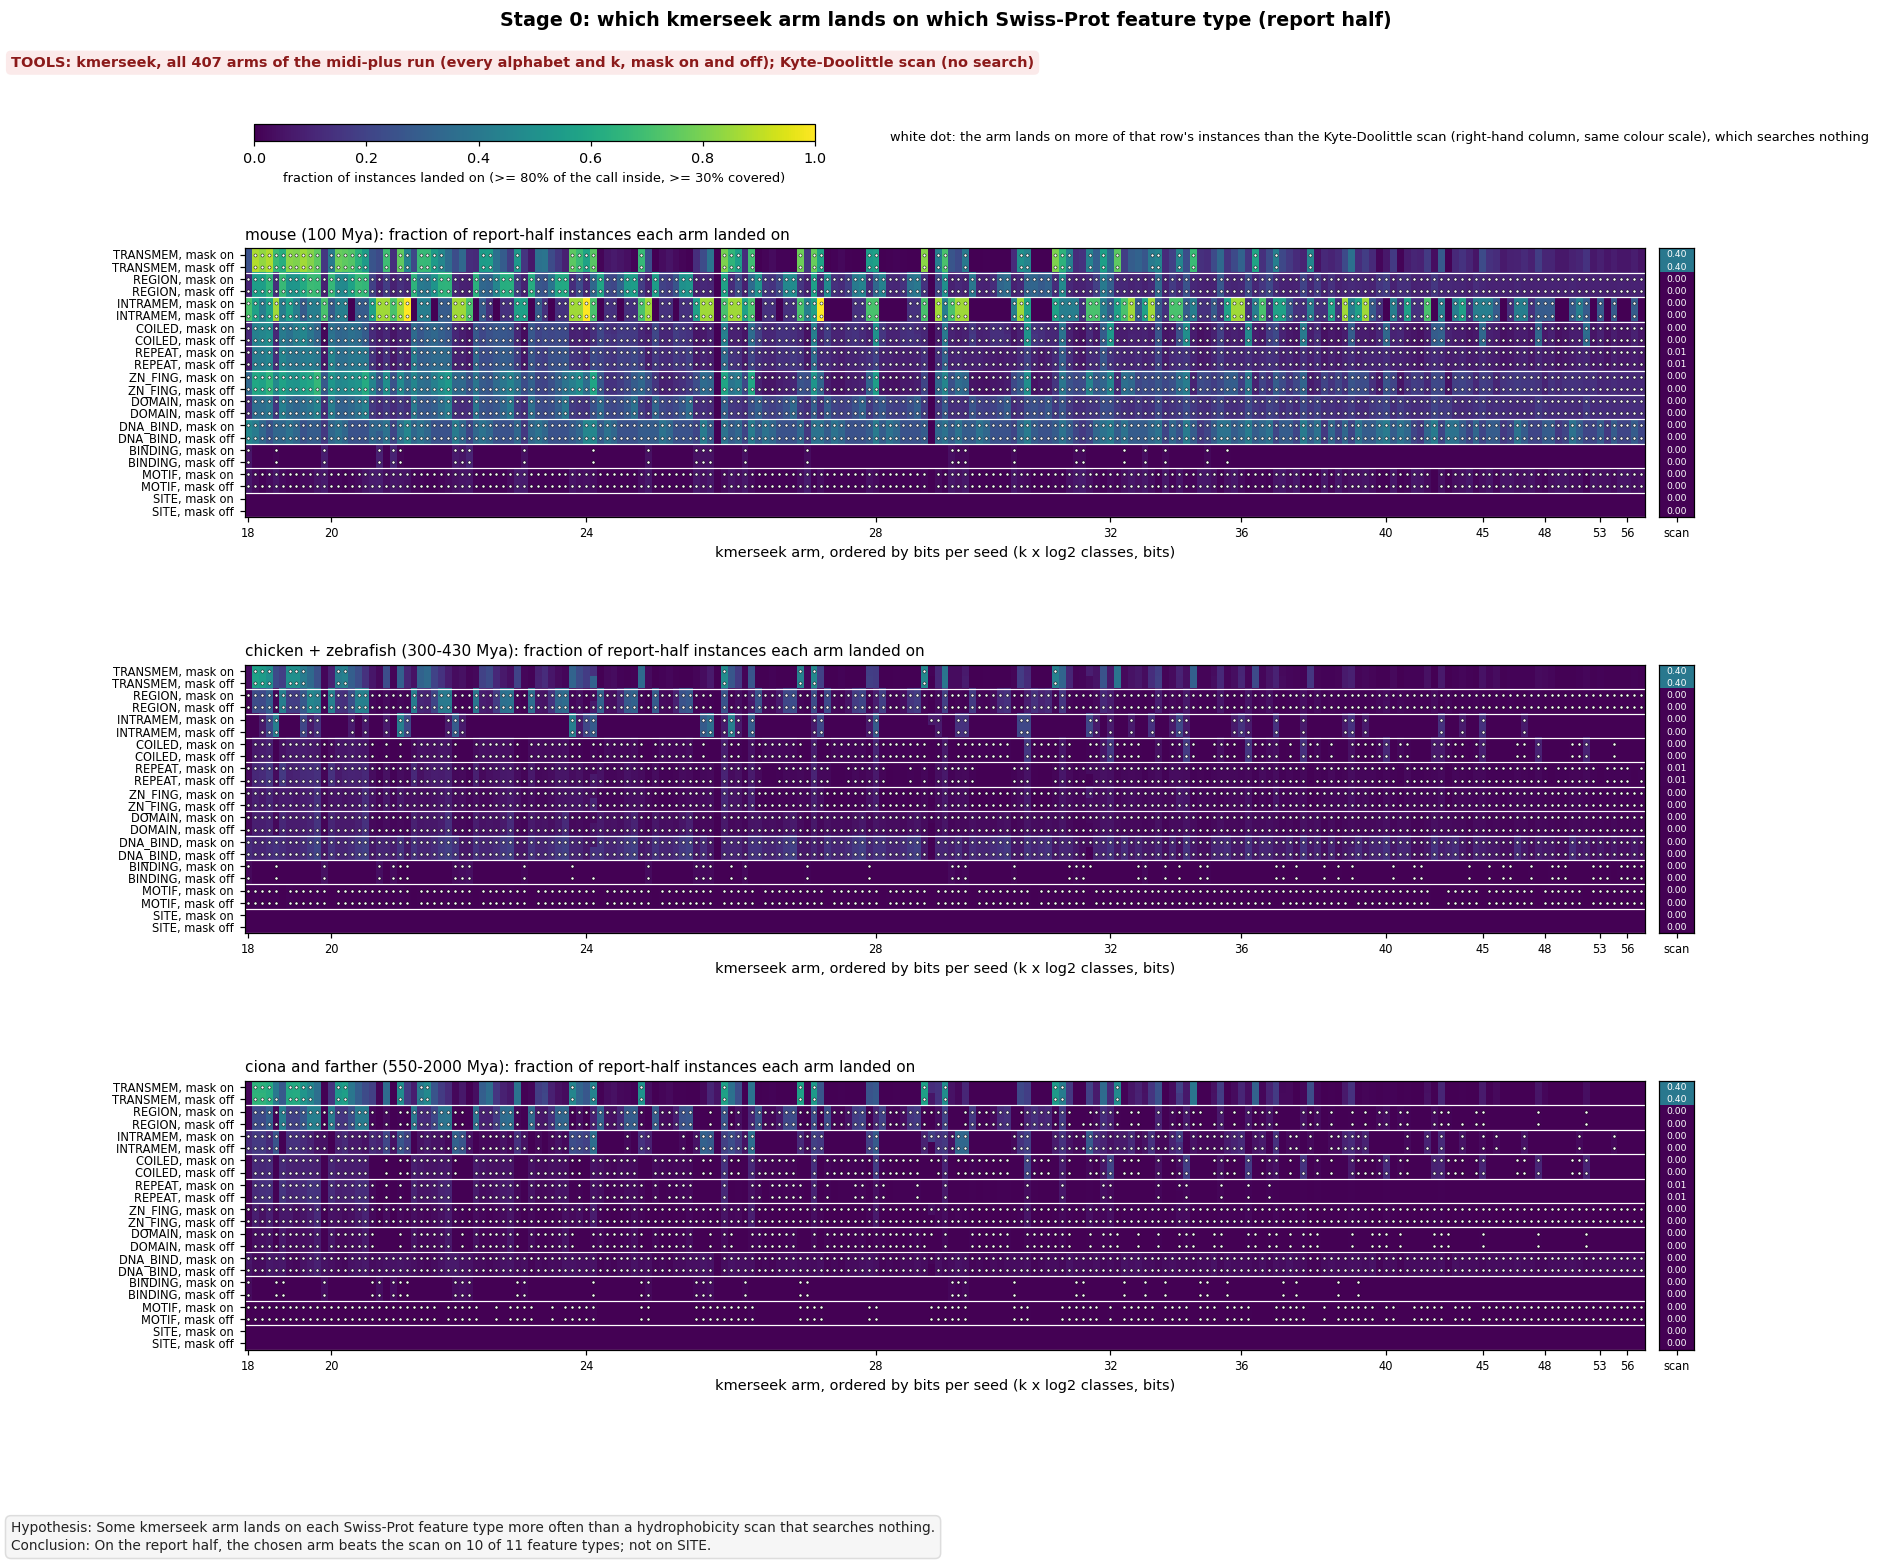

In [4]:
from matplotlib.colors import Normalize

GROUPS = {
    "mouse (100 Mya)": ["mouse"],
    "chicken + zebrafish (300-430 Mya)": ["chicken", "zebrafish"],
    "ciona and farther (550-2000 Mya)": [
        "ciona",
        "fly",
        "worm",
        "yeast",
        "arabidopsis",
        "ecoli",
    ],
}
TYPES = READOUT["pfam_id"].to_list()  # ordered by the chosen arm's report-half fraction
g = (
    ST0.filter(pl.col("half") == "report")
    .with_columns(
        group=pl.col("species").replace_strict(
            {s: k for k, v in GROUPS.items() for s in v}, return_dtype=pl.String
        )
    )
    .group_by("group", "arm", "pfam_id", "mask_on", "bits_per_seed", "alphabet", "k")
    .agg(
        frac=pl.col("n_landed").sum() / pl.col("n_instances").sum(),
        scan=pl.col("scan_frac_landed").first(),
    )
)
# The scan does not depend on the arm or the species: one value per feature type.
SCAN_REPORT = dict(
    DEN.filter(pl.col("half") == "report")
    .select("pfam_id", pl.col("scan_landed") / pl.col("n_instances"))
    .iter_rows()
)
x_order = (
    ARMS.filter("mask_on")
    .sort("bits_per_seed", "alphabet", "k")
    .select("alphabet", "k", "bits_per_seed")
)
vmax = float(g["frac"].max())
norm = Normalize(0, vmax)
cmap = plt.get_cmap("viridis")

fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(3, 2, width_ratios=[40, 1], hspace=0.55, wspace=0.02)
for gi, grp in enumerate(GROUPS):
    ax = fig.add_subplot(gs[gi, 0])
    axs = fig.add_subplot(gs[gi, 1])
    rows, labels, scan_vals = [], [], []
    for t in TYPES:
        for mask in (True, False):
            s = g.filter(
                (pl.col("group") == grp)
                & (pl.col("pfam_id") == t)
                & (pl.col("mask_on") == mask)
            ).join(x_order, on=["alphabet", "k", "bits_per_seed"], how="right")
            rows.append(s["frac"].to_numpy())
            labels.append(f"{t}, mask {'on' if mask else 'off'}")
            scan_vals.append(SCAN_REPORT[t])
    M = np.vstack(rows)
    ax.imshow(M, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    # A dot marks every arm that lands on more of that row's instances than the scan.
    yy, xx = np.nonzero(M > np.array(scan_vals)[:, None])
    ax.scatter(xx, yy, s=4, c="white", edgecolors="black", linewidths=0.3, marker="o")
    ax.set_yticks(range(len(labels)), labels, fontsize=7.5)
    ticks = [
        i
        for i in range(x_order.height)
        if i == 0
        or x_order["bits_per_seed"][i] // 4 != x_order["bits_per_seed"][i - 1] // 4
    ]
    ax.set_xticks(
        ticks, [f"{x_order['bits_per_seed'][i]:.0f}" for i in ticks], fontsize=7.5
    )
    ax.set_xlabel("kmerseek arm, ordered by bits per seed (k x log2 classes, bits)")
    ax.set_title(
        f"{grp}: fraction of report-half instances each arm landed on",
        fontsize=10,
        loc="left",
    )
    for yb in np.arange(1.5, len(labels), 2):
        ax.axhline(yb, color="white", lw=0.8)
    axs.imshow(np.array(scan_vals)[:, None], aspect="auto", cmap=cmap, norm=norm)
    for i, v in enumerate(scan_vals):
        axs.text(
            0,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="white" if v < vmax * 0.6 else "black",
        )
    axs.set_xticks([0], ["scan"], fontsize=7.5)
    axs.set_yticks([])
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = fig.add_axes([0.13, 0.955, 0.3, 0.012])
fig.colorbar(sm, cax=cax, orientation="horizontal").set_label(
    "fraction of instances landed on (>= 80% of the call inside, >= 30% covered)",
    fontsize=8.5,
)
fig.text(
    0.47,
    0.958,
    "white dot: the arm lands on more of that row's instances than the "
    "Kyte-Doolittle scan (right-hand column, same colour scale), which searches nothing",
    fontsize=8.5,
    va="center",
)
mu.finish_figure(
    fig,
    FIG / "244_stage0_arm_by_feature_type.png",
    tools=f"kmerseek, all {len(KM_ARMS)} arms of the midi-plus run (every alphabet and k, mask on and off); Kyte-Doolittle scan (no search)",
    hypothesis="Some kmerseek arm lands on each Swiss-Prot feature type more often than a hydrophobicity scan that searches nothing.",
    conclusion=f"On the report half, the chosen arm beats the scan on {len(beats)} of {len(TYPES)} feature types; not on {', '.join(no_arm) if no_arm else 'none'}.",
    title="Stage 0: which kmerseek arm lands on which Swiss-Prot feature type (report half)",
    layout=False,
)

## The candidates: criteria 1 to 4 on the report half

1. The feature is under 60 aa.
2. The arm Stage 0 chose for the feature's type lands on it, mask on, and so does at least
   one mask-on arm of a different alphabet. The row's target protein is the one the chosen
   arm's best landing call took the label from.
3. On the same instance and species, each structure tool (Foldseek, ProstT5, Reseek) has
   *no call* or a call that *spills*. phmmer, MMseqs2 and MMseqs2 iterative are recorded
   the same way. The loosened form also allows a structure tool *inside with lower IoU*.
4. Identity between the human region and the target region is 50% to 90%.

Criterion 5 (species distance) keeps mouse out unless too few cases pass. The table marks
which rows came in under a loosening.

   2084  report-half instances under 60 aa
   7634  x species where the chosen arm lands (criterion 2a)
   7344  ... and an arm of another alphabet lands too (criterion 2)
    223  ... and identity 50-90% (criterion 4)
    183  ... and no structure tool reaches kmerseek's IoU (criterion 3, loosened)
    156  ... and every structure tool has no call or spills (criterion 3)
     87  ... and the species is not mouse (criterion 5)

Outcome of each comparison tool on the rows passing criteria 1, 2 and 4:
shape: (6, 5)
┌────────────────────────────┬─────────┬───────────────────┬─────────────────────┬────────┐
│ variable                   ┆ no call ┆ inside, lower IoU ┆ equal or higher IoU ┆ spills │
│ ---                        ┆ ---     ┆ ---               ┆ ---                 ┆ ---    │
│ str                        ┆ u32     ┆ u32               ┆ u32                 ┆ u32    │
╞════════════════════════════╪═════════╪═══════════════════╪═════════════════════╪════════╡
│ MMseqs2 iterative|c

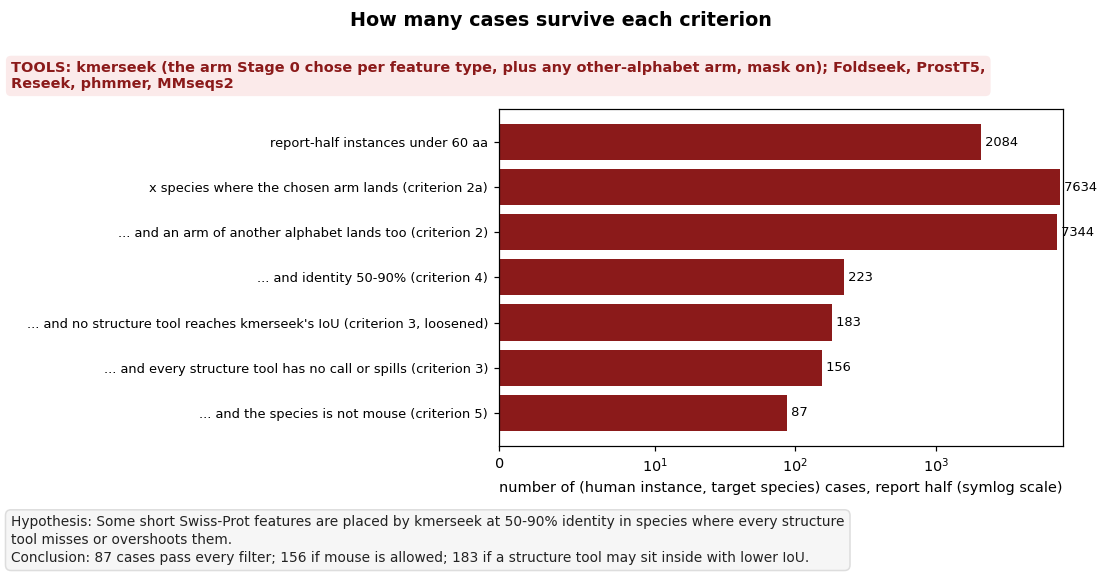

In [5]:
REP = INST.filter((pl.col("half") == "report") & (pl.col("feature_length") < 60))
LAND = KM.filter(pl.col("mask_on") & pl.col("landed"))
chosen_rows = LAND.filter(
    pl.col("arm") == pl.col("pfam_id").replace_strict(CHOSEN, default=None)
).select(
    KEY
    + [
        "species",
        pl.col("arm").alias("chosen_arm"),
        "land_iou",
        "land_inside",
        "land_cover",
        "land_qstart",
        "land_qend",
        "land_target_acc",
        "land_tstart",
        "land_tend",
        "land_t_feat_start",
        "land_t_feat_end",
        "n_landed_targets",
    ]
)
C = REP.join(chosen_rows, on=KEY, how="inner")
n_c2a = C.height
other = (
    LAND.join(C.select(KEY + ["species"]).unique(), on=KEY + ["species"], how="semi")
    .with_columns(
        chosen_alpha=pl.col("pfam_id").replace_strict(CHOSEN_ALPHABET, default=None)
    )
    .filter(pl.col("alphabet") != pl.col("chosen_alpha"))
    .sort(["land_iou", "arm"], descending=[True, False])
    .group_by(KEY + ["species"])
    .agg(
        other_arm=pl.col("arm").first(),
        other_iou=pl.col("land_iou").first(),
        n_other_alphabets=pl.col("alphabet").n_unique(),
    )
)
agree = LAND.group_by(KEY + ["species"]).agg(
    n_arms_landed=pl.col("arm").n_unique(),
    n_alphabets_landed=pl.col("alphabet").n_unique(),
    arms_landed=pl.col("arm").sort().str.join(";"),
)
C = C.join(other, on=KEY + ["species"], how="inner").join(
    agree, on=KEY + ["species"], how="left"
)
n_c2 = C.height

for arm, lab in he.COMPARISON_ARMS.items():
    c = L.filter(pl.col("arm") == arm).select(
        KEY
        + [
            "species",
            "n_overlapping_calls",
            "best_iou",
            "any_inside_half",
            "best_inside",
            "best_qstart",
            "best_qend",
            "best_target_acc",
            "best_tstart",
            "best_tend",
        ]
    )
    c = c.rename({x: f"{lab}|{x}" for x in c.columns if x not in KEY + ["species"]})
    C = C.join(c, on=KEY + ["species"], how="left").with_columns(
        he.classify_comparison(pl.col("land_iou"), prefix=f"{lab}|").alias(
            f"{lab}|category"
        )
    )

# Identity in the matched region, from the residues themselves.
hseq = he.sequences("human", set(C["accession"]))
rows = []
for sp in C["species"].unique().to_list():
    sub = C.filter(pl.col("species") == sp)
    tseq = he.sequences(sp, set(sub["land_target_acc"]))
    for r in sub.iter_rows(named=True):
        q, t = he.region_residues(
            hseq[r["accession"]],
            tseq[r["land_target_acc"]],
            r["land_qstart"],
            r["land_qend"],
            r["land_tstart"],
            r["land_tend"],
        )
        n_id, n = he.identity(q, t)
        rows.append(
            {
                **{k: r[k] for k in KEY + ["species"]},
                "n_identical": n_id,
                "region_length": n,
                "identity_pct": 100 * n_id / n,
            }
        )
C = C.join(pl.DataFrame(rows), on=KEY + ["species"], how="left")

STRUCT = [f"{lab}|category" for lab in he.STRUCTURE_ARMS.values()]
C = C.with_columns(
    c3_strict=pl.all_horizontal(
        [pl.col(c).is_in(["no call", "spills"]) for c in STRUCT]
    ),
    c3_loose=pl.all_horizontal([pl.col(c) != "equal or higher IoU" for c in STRUCT]),
    c4=(pl.col("identity_pct") >= 50) & (pl.col("identity_pct") <= 90),
    mya=pl.col("species").replace_strict(he.SPECIES_MYA, return_dtype=pl.Int64),
    low_confidence=(
        (pl.col("mean_plddt_region") < 70) | (pl.col("disorder_fraction_region") >= 0.5)
    ).fill_null(False),
    type_rank=he.type_rank(pl.col("feature_label")),
)
funnel = [
    ("report-half instances under 60 aa", REP.height, None),
    ("x species where the chosen arm lands (criterion 2a)", n_c2a, None),
    ("... and an arm of another alphabet lands too (criterion 2)", n_c2, None),
    ("... and identity 50-90% (criterion 4)", C.filter("c4").height, None),
    (
        "... and no structure tool reaches kmerseek's IoU (criterion 3, loosened)",
        C.filter("c4", "c3_loose").height,
        None,
    ),
    (
        "... and every structure tool has no call or spills (criterion 3)",
        C.filter("c4", "c3_strict").height,
        None,
    ),
    (
        "... and the species is not mouse (criterion 5)",
        C.filter("c4", "c3_strict", pl.col("species") != "mouse").height,
        None,
    ),
]
for lab, n, _ in funnel:
    print(f"{n:>7}  {lab}")
print()
print("Outcome of each comparison tool on the rows passing criteria 1, 2 and 4:")
print(
    C.filter("c4")
    .select([c for c in C.columns if c.endswith("|category")])
    .unpivot()
    .group_by("variable", "value")
    .len()
    .pivot(on="value", index="variable", values="len")
    .fill_null(0)
)

fig, ax = plt.subplots(figsize=(10, 3.8))
yy = np.arange(len(funnel))
ax.barh(yy, [n for _, n, _ in funnel], color="#8B1A1A")
for y, (_, n, _) in zip(yy, funnel):
    ax.text(n, y, f" {n}", va="center", fontsize=8.5)
ax.set_yticks(yy, [lab for lab, _, _ in funnel], fontsize=8.5)
ax.invert_yaxis()
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel(
    "number of (human instance, target species) cases, report half (symlog scale)"
)
mu.finish_figure(
    fig,
    FIG / "244_candidate_funnel.png",
    tools="kmerseek (the arm Stage 0 chose per feature type, plus any other-alphabet arm, mask on); Foldseek, ProstT5, Reseek, phmmer, MMseqs2",
    hypothesis="Some short Swiss-Prot features are placed by kmerseek at 50-90% identity in species where every structure tool misses or overshoots them.",
    conclusion=f"{funnel[-1][1]} cases pass every filter; {funnel[-2][1]} if mouse is allowed; {funnel[-3][1]} if a structure tool may sit inside with lower IoU.",
    title="How many cases survive each criterion",
)

In [6]:
# Tiers, loosened in the order the brief gives: criterion 5 first, then criterion 3.
P = C.filter("c4", "c3_loose").with_columns(
    admitted_under=pl.when(pl.col("c3_strict") & (pl.col("species") != "mouse"))
    .then(pl.lit("all criteria"))
    .when(pl.col("c3_strict"))
    .then(pl.lit("criterion 5 loosened (mouse allowed)"))
    .otherwise(pl.lit("criteria 5 and 3 loosened (structure tool inside, lower IoU)"))
)
n_strict = P.filter(pl.col("admitted_under") == "all criteria").height
allowed = ["all criteria"]
if n_strict < 10:
    allowed.append("criterion 5 loosened (mouse allowed)")
if P.filter(pl.col("admitted_under").is_in(allowed)).height < 10:
    allowed.append("criteria 5 and 3 loosened (structure tool inside, lower IoU)")
print(f"cases under all criteria: {n_strict}; tiers used for the ranking: {allowed}")

# Identity of the enclosing Pfam domain, from bin/parse_domain_identity.py (per species).
pf = mu.load_human_truth().select(
    "accession", pfam_domain="pfam_id", p_start="domain_start", p_end="domain_end"
)
ident_parts = []
for sp in he.SPECIES:
    idt = pl.read_parquet(mu.IDENTITY_DIR / f"{sp}.domain_identity.parquet").select(
        "accession",
        pfam_domain="pfam_id",
        p_start="domain_start",
        p_end="domain_end",
        pfam_identity_pct="best_pident",
    )
    ident_parts.append(idt.with_columns(species=pl.lit(sp)))
IDT = pl.concat(ident_parts)
enc = (
    P.select(KEY + ["species"])
    .join(pf, on="accession", how="inner")
    .with_columns(
        ov=pl.min_horizontal("domain_end", "p_end")
        - pl.max_horizontal("domain_start", "p_start")
    )
    .filter(pl.col("ov") > 0)
    .join(
        IDT, on=["accession", "pfam_domain", "p_start", "p_end", "species"], how="left"
    )
    .sort(["ov", "pfam_domain"], descending=[True, False])
    .group_by(KEY + ["species"])
    .agg(pl.col("pfam_domain").first(), pl.col("pfam_identity_pct").first())
)
P = P.join(enc, on=KEY + ["species"], how="left")

RANK_COLS = [
    "kd_landed",
    "low_confidence",
    "mya",
    "n_arms_landed",
    "type_rank",
    "land_iou",
    "accession",
    "domain_start",
]
RANK_DESC = [False, True, True, True, False, True, False, False]
P = P.sort(RANK_COLS, descending=RANK_DESC)

cols = {
    "hgnc_symbol": "gene",
    "accession": "query",
    "pfam_id": "feature_type",
    "note": "swissprot_description",
    "feature_label": "criterion6_class",
    "domain_start": "feature_start",
    "domain_end": "feature_end",
    "feature_length": "feature_length_aa",
    "type_split": "231_type_split",
    "species": "species",
    "mya": "species_mya",
    "land_target_acc": "target",
    "chosen_arm": "kmerseek_chosen_arm",
    "land_iou": "kmerseek_iou",
    "land_inside": "frac_call_inside_feature",
    "land_cover": "frac_feature_covered",
    "other_arm": "kmerseek_best_other_alphabet_arm",
    "other_iou": "kmerseek_other_arm_iou",
    "n_arms_landed": "n_kmerseek_arms_landed",
    "n_alphabets_landed": "n_kmerseek_alphabets_landed",
    "arms_landed": "kmerseek_arms_landed",
    "n_identical": "n_identical",
    "region_length": "region_length_aa",
    "identity_pct": "identity_pct_region",
    "pfam_domain": "enclosing_pfam_domain",
    "pfam_identity_pct": "enclosing_pfam_identity_pct",
    "kd_landed": "kd_scan_landed",
    "kd_best_iou": "kd_scan_best_iou",
    "mean_plddt_region": "mean_plddt_feature",
    "frac_plddt_lt70_region": "frac_plddt_lt70_feature",
    "disorder_fraction_region": "disorder_fraction_feature",
    "low_confidence": "criterion7_low_plddt_or_disordered",
    "admitted_under": "admitted_under",
}
comp_cols = []
for lab in he.COMPARISON_ARMS.values():
    comp_cols += [
        pl.col(f"{lab}|best_iou").fill_null(0.0).round(3).alias(f"{lab}_iou"),
        pl.col(f"{lab}|category").alias(f"{lab}_category"),
    ]
CSV = P.select([pl.col(k).alias(v) for k, v in cols.items()] + comp_cols).with_columns(
    pl.col("kmerseek_iou").round(3),
    pl.col("kmerseek_other_arm_iou").round(3),
    pl.col("identity_pct_region").round(1),
    pl.col("mean_plddt_feature").round(1),
    pl.col("disorder_fraction_feature").round(3),
    pl.col("frac_call_inside_feature").round(3),
    pl.col("frac_feature_covered").round(3),
)
CSV.write_csv(TAB / "244_hero_candidates.csv")
print(f"wrote {TAB / '244_hero_candidates.csv'}: {CSV.height} rows")
print(
    CSV.group_by("admitted_under", "kd_scan_landed")
    .len()
    .sort("admitted_under", "kd_scan_landed")
)
print()
print(
    "Rows by feature type (all criteria / loosened), and how many of each the scan landed on:"
)
print(
    CSV.group_by("feature_type")
    .agg(
        all_criteria=(pl.col("admitted_under") == "all criteria").sum(),
        all_criteria_scan_landed=(
            (pl.col("admitted_under") == "all criteria") & pl.col("kd_scan_landed")
        ).sum(),
        any_tier=pl.len(),
        any_tier_scan_landed=pl.col("kd_scan_landed").sum(),
    )
    .sort("all_criteria", descending=True)
)
print("\nBINDING and INTRAMEM rows under all criteria, by gene and description:")
print(
    CSV.filter(
        (pl.col("admitted_under") == "all criteria")
        & pl.col("feature_type").is_in(["BINDING", "INTRAMEM"])
    )
    .group_by("feature_type", "swissprot_description", "feature_length_aa")
    .agg(n=pl.len(), genes=pl.col("gene").unique().sort().str.join(", "))
    .sort("feature_type")
)

cases under all criteria: 87; tiers used for the ranking: ['all criteria']


wrote ../tables/244_hero_candidates.csv: 183 rows
shape: (5, 3)
┌──────────────────────────────────────────────────────────────┬────────────────┬─────┐
│ admitted_under                                               ┆ kd_scan_landed ┆ len │
│ ---                                                          ┆ ---            ┆ --- │
│ str                                                          ┆ bool           ┆ u32 │
╞══════════════════════════════════════════════════════════════╪════════════════╪═════╡
│ all criteria                                                 ┆ false          ┆ 86  │
│ all criteria                                                 ┆ true           ┆ 1   │
│ criteria 5 and 3 loosened (structure tool inside, lower IoU) ┆ false          ┆ 26  │
│ criteria 5 and 3 loosened (structure tool inside, lower IoU) ┆ true           ┆ 1   │
│ criterion 5 loosened (mouse allowed)                         ┆ false          ┆ 69  │
└───────────────────────────────────────────────────────

## Top 10, and the cases a scan also finds

One row per human feature: a feature that passes in several species is shown once, at its
highest-ranked species, with the other species listed (`species_passing`). Without this the
top 10 holds the same feature up to three times. The CSV keeps every row.

Order: cases the Kyte-Doolittle scan did not land on come before every case it did. Within
that, criterion 7 first (mean pLDDT under 70 over the feature, or at least half its residues
predicted disordered by metapredict), then species distance, then the number of mask-on
kmerseek arms that land on the instance, then the feature-type class of criterion 6, then
kmerseek's IoU.

In [7]:
POOL = P.filter(pl.col("admitted_under").is_in(allowed))


def one_per_instance(d):
    # Keep each human feature once, at its highest-ranked species; list the others.
    others = d.group_by(KEY, maintain_order=True).agg(
        n_species_passing=pl.col("species").n_unique(),
        species_passing=pl.col("species").str.join(", "),
    )
    return d.unique(subset=KEY, keep="first", maintain_order=True).join(
        others, on=KEY, how="left"
    )


TOP = one_per_instance(POOL.filter(~pl.col("kd_landed"))).head(10)
SCAN_FOUND = one_per_instance(POOL.filter(pl.col("kd_landed")))
print(
    f"passing rows not landed on by the scan: {POOL.filter(~pl.col('kd_landed')).height}, "
    f"on {POOL.filter(~pl.col('kd_landed')).select(KEY).n_unique()} distinct human features"
)
view = lambda d: d.select(
    pl.col("hgnc_symbol").alias("gene"),
    "accession",
    "pfam_id",
    pl.col("note").str.slice(0, 28),
    pl.col("feature_length").alias("len"),
    "species",
    pl.col("land_target_acc").alias("target"),
    pl.col("chosen_arm")
    .map_elements(he.arm_short, return_dtype=pl.String)
    .alias("chosen arm"),
    pl.col("land_iou").round(2).alias("km IoU"),
    pl.col("identity_pct").round(0).alias("id %"),
    pl.col("n_arms_landed").alias("arms"),
    *[pl.col(f"{lab}|category").alias(lab) for lab in he.STRUCTURE_ARMS.values()],
    pl.col("phmmer|category").alias("phmmer"),
    pl.col("mean_plddt_region").round(0).alias("pLDDT"),
    pl.col("disorder_fraction_region").round(2).alias("disorder"),
    "admitted_under",
    "species_passing",
)
print(f"Top {TOP.height} (the Kyte-Doolittle scan did not land on these):")
print(view(TOP))
print()
print(f"Found by a scan that searches nothing: {SCAN_FOUND.height} cases, first 10:")
print(view(SCAN_FOUND.head(10)))

passing rows not landed on by the scan: 86, on 49 distinct human features
Top 10 (the Kyte-Doolittle scan did not land on these):
shape: (10, 19)
┌─────────┬───────────┬──────────┬─────────────────┬─────┬─────────────┬────────────┬──────────────────┬────────┬──────┬──────┬──────────┬─────────┬─────────┬─────────────────┬───────┬──────────┬────────────────┬─────────────────┐
│ gene    ┆ accession ┆ pfam_id  ┆ note            ┆ len ┆ species     ┆ target     ┆ chosen arm       ┆ km IoU ┆ id % ┆ arms ┆ Foldseek ┆ ProstT5 ┆ Reseek  ┆ phmmer          ┆ pLDDT ┆ disorder ┆ admitted_under ┆ species_passing │
│ ---     ┆ ---       ┆ ---      ┆ ---             ┆ --- ┆ ---         ┆ ---        ┆ ---              ┆ ---    ┆ ---  ┆ ---  ┆ ---      ┆ ---     ┆ ---     ┆ ---             ┆ ---   ┆ ---      ┆ ---            ┆ ---             │
│ str     ┆ str       ┆ str      ┆ str             ┆ i64 ┆ str         ┆ str        ┆ str              ┆ f64    ┆ f64  ┆ u32  ┆ str      ┆ str     ┆ str     ┆ st

## Alignments of the top 10

For each case: the human region and the target region as residues, one above the other,
with `|` under an identical residue and the coordinates on both proteins (1-based,
inclusive). Then the two hp_pbotc_1st_ed2 class strings (H = ACFILMPVWY,
P = DEGHKNQRST) with their own match line, and `^` under the longest run of identical
classes. The brief asks for hp_pbotc_1st_ed2 classes whatever arm made the call. When the
chosen arm uses another alphabet (for example hp_thomas_dill_no_c2 for DOMAIN, sdm12 for
BINDING), kmerseek's exact k-mer matches are in that arm's own classes, so the
hp_pbotc_1st_ed2 strings need not agree along the whole region.

In [8]:
for i, r in enumerate(TOP.iter_rows(named=True), start=1):
    hs = he.sequences("human", {r["accession"]})[r["accession"]]
    ts = he.sequences(r["species"], {r["land_target_acc"]})[r["land_target_acc"]]
    print(
        f"=== {i}. {r['hgnc_symbol']} ({r['accession']}) {r['pfam_id']} "
        f"\"{r['note']}\" {r['domain_start']}-{r['domain_end']} ({r['feature_length']} aa) "
        f"-> {r['species']} {r['land_target_acc']}, kmerseek {he.arm_short(r['chosen_arm'])}, "
        f"IoU {r['land_iou']:.2f}"
    )
    print(
        he.format_alignment(
            f"human {r['hgnc_symbol']}",
            f"{r['species']} {r['land_target_acc']}",
            hs,
            ts,
            r["land_qstart"],
            r["land_qend"],
            r["land_tstart"],
            r["land_tend"],
        )
    )
    print()

=== 1. ROS1 (P08922) BINDING "ligand: ATP" 1951-1959 (9 aa) -> yeast P38070, kmerseek sdm12 k6, IoU 0.80
6 of 10 residues identical (60%); query 1950-1959, target 133-142
human ROS1         1950 LLGSGAFGEV 1959
                         || || | |
yeast P38070        133 VLGQGAYGKV 142

hp_pbotc_1st_ed2 classes (H = ACFILMPVWY, P = DEGHKNQRST); longest run of identical classes: 10 positions, query 1950-1959
human ROS1         1950 HHPPPHHPPH
                        ||||||||||
yeast P38070        133 HHPPPHHPPH
                        ^^^^^^^^^^


=== 2. COL9A1 (P20849) DOMAIN "Collagen-like 6" 587-643 (57 aa) -> zebrafish Q5U3G1, kmerseek hp_thomas_dill_no_c2 k19, IoU 0.46
16 of 30 residues identical (53%); query 585-614, target 46-75
human COL9A1        585 AGEKGSTGAPGKPGQMGNSGKPGQQGPPGE 614
                        |||||  |||| ||  |  |  |  |  | 
zebrafish Q5U3G1     46 AGEKGEKGAPGRPGRVGPTGEQGPPGDKGQ 75

hp_pbotc_1st_ed2 classes (H = ACFILMPVWY, P = DEGHKNQRST); longest run of identical 

## One figure per candidate

Each protein is a thin line with its Swiss-Prot features as boxes labelled by type; the
feature being scored has a heavy outline. Under each protein, one row per tool shows that
tool's call on this protein: the best call of the feature's type that overlaps the instance.
The target panel shows a comparison tool's call only when it is on the same target protein
as kmerseek's.

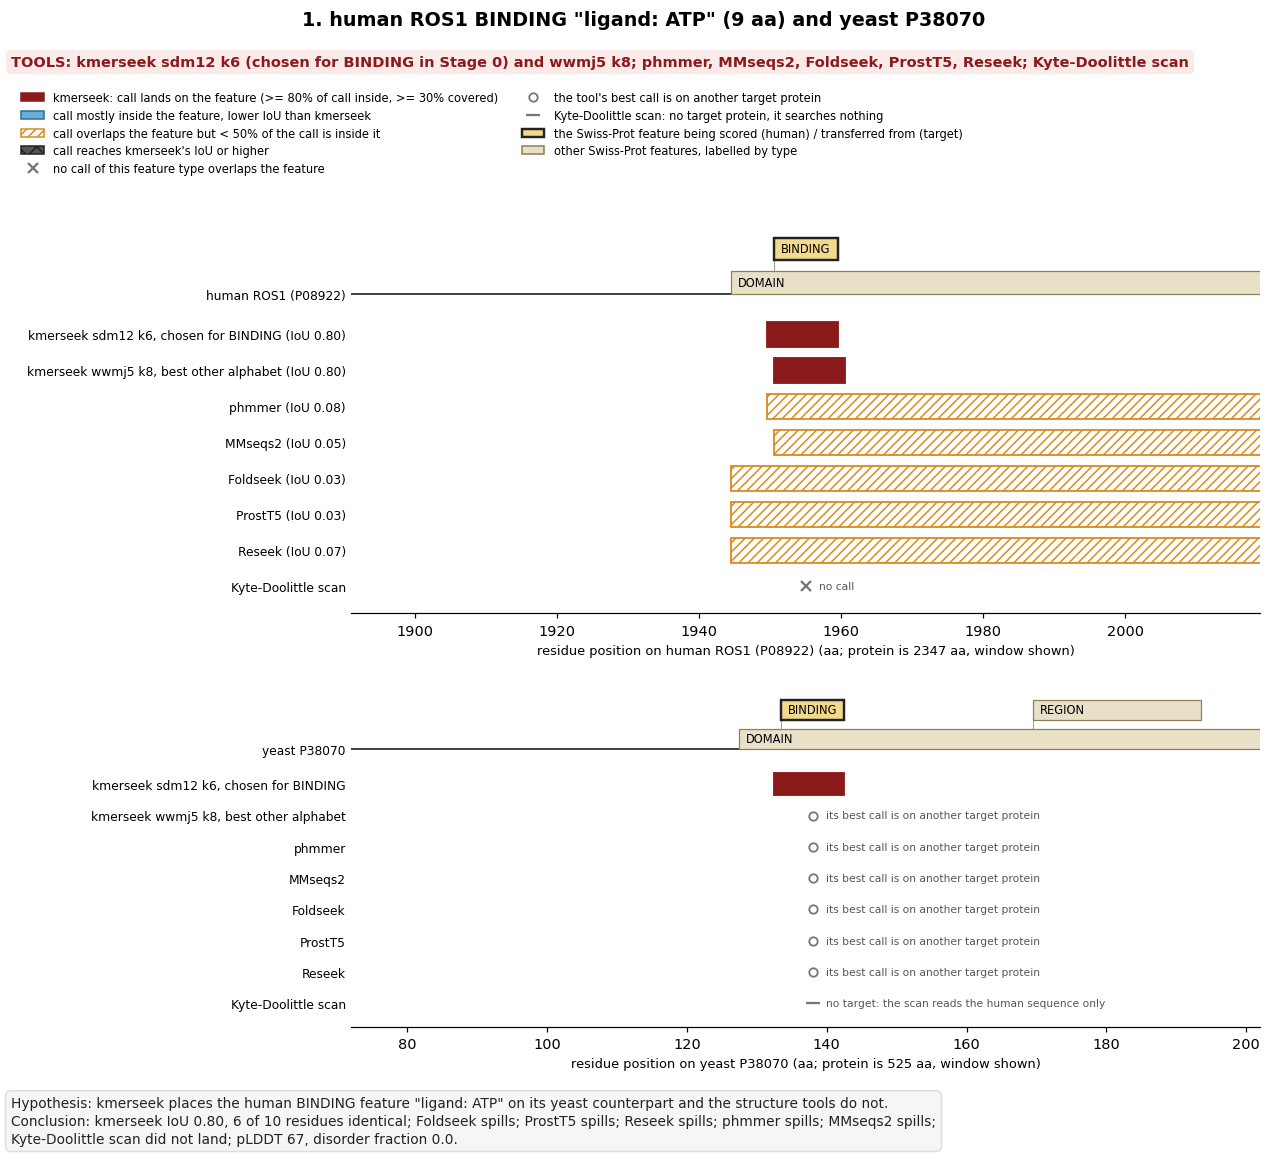

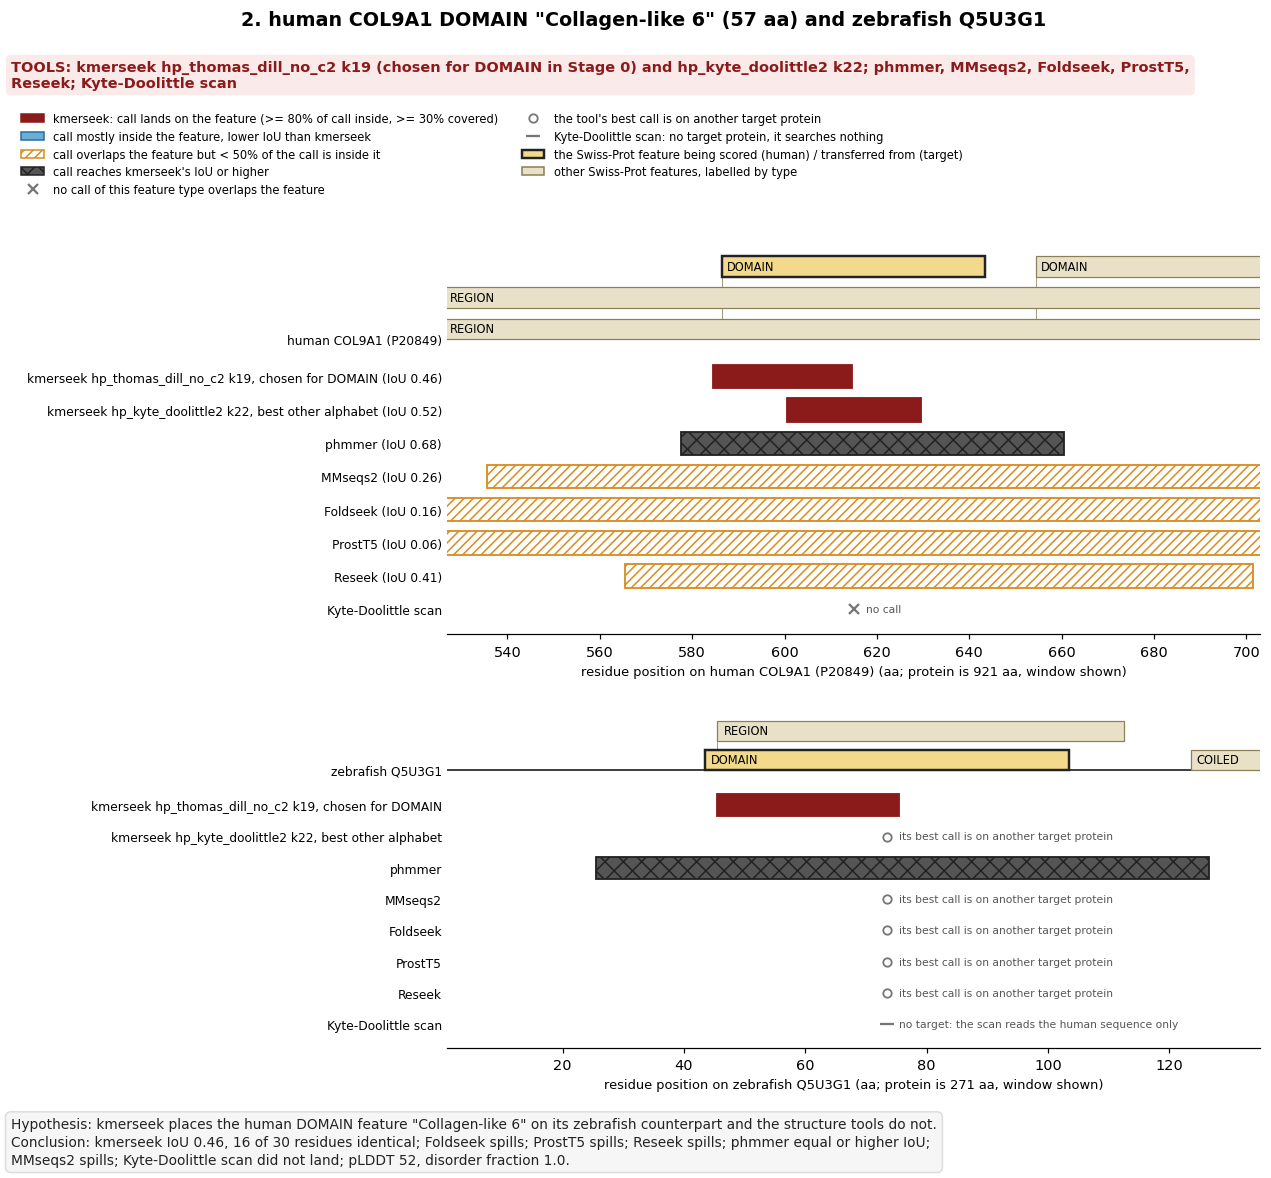

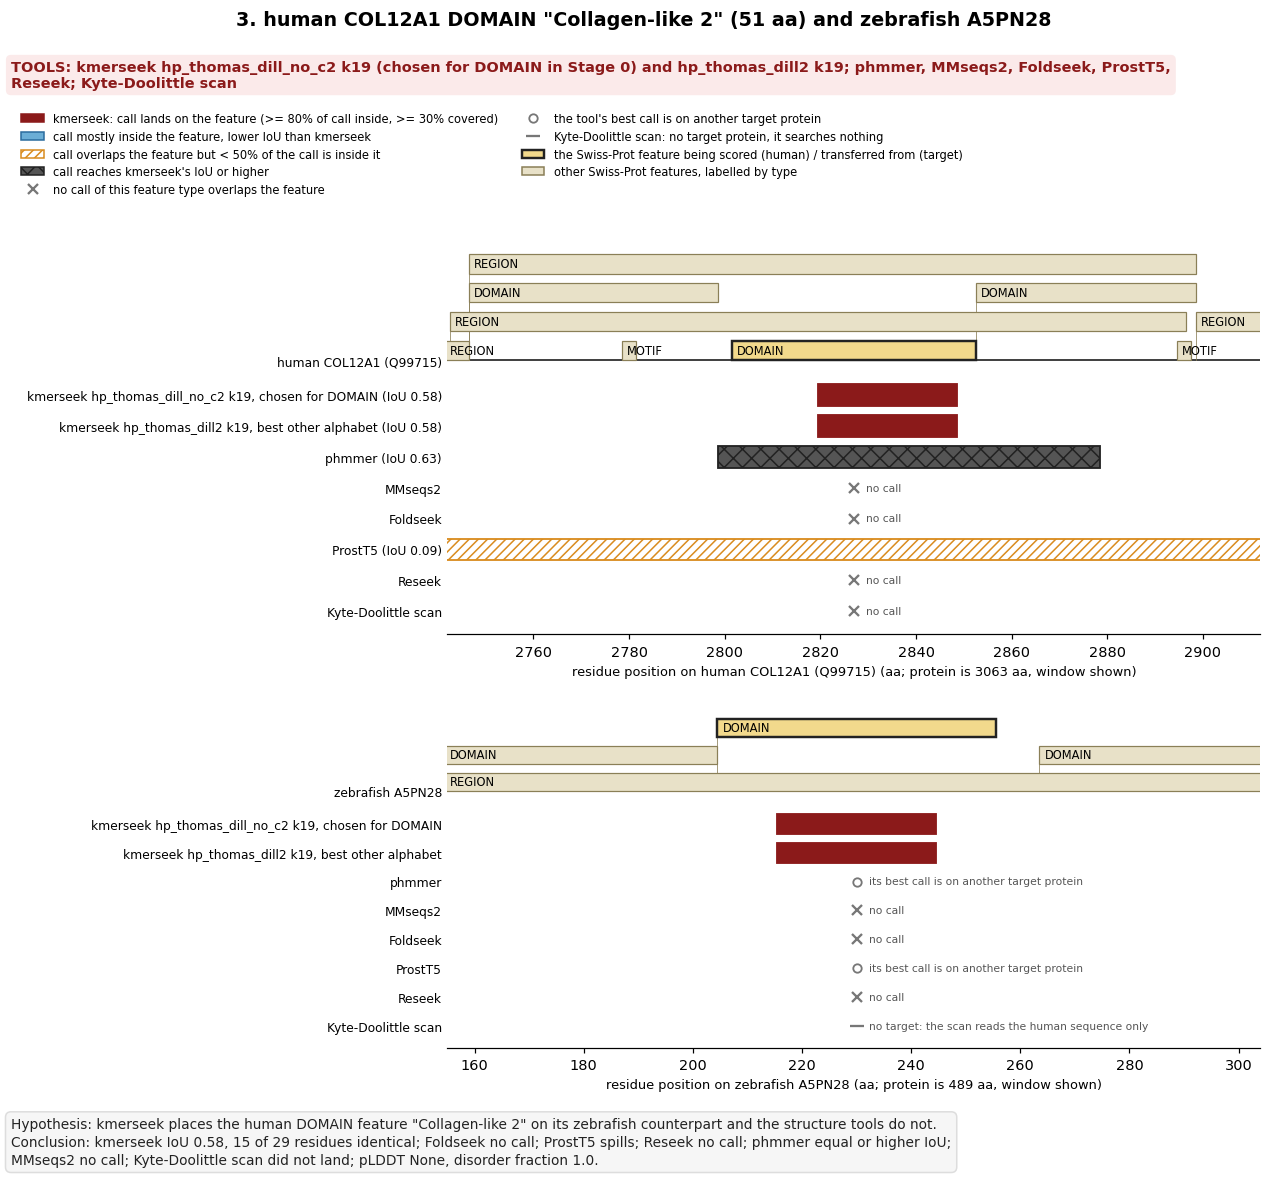

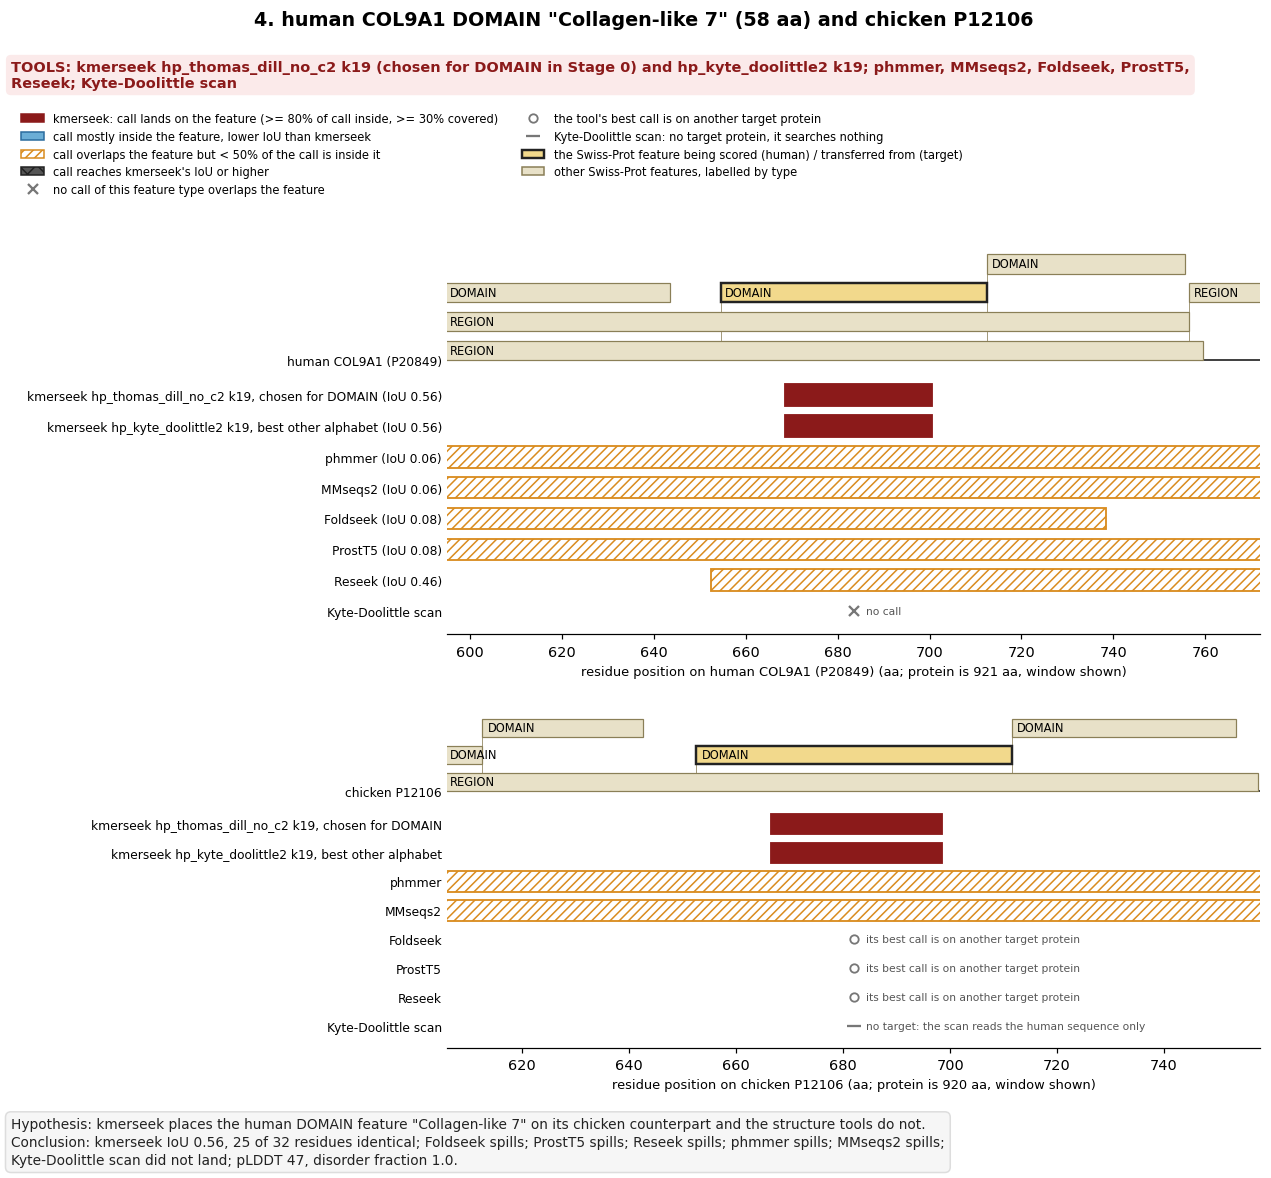

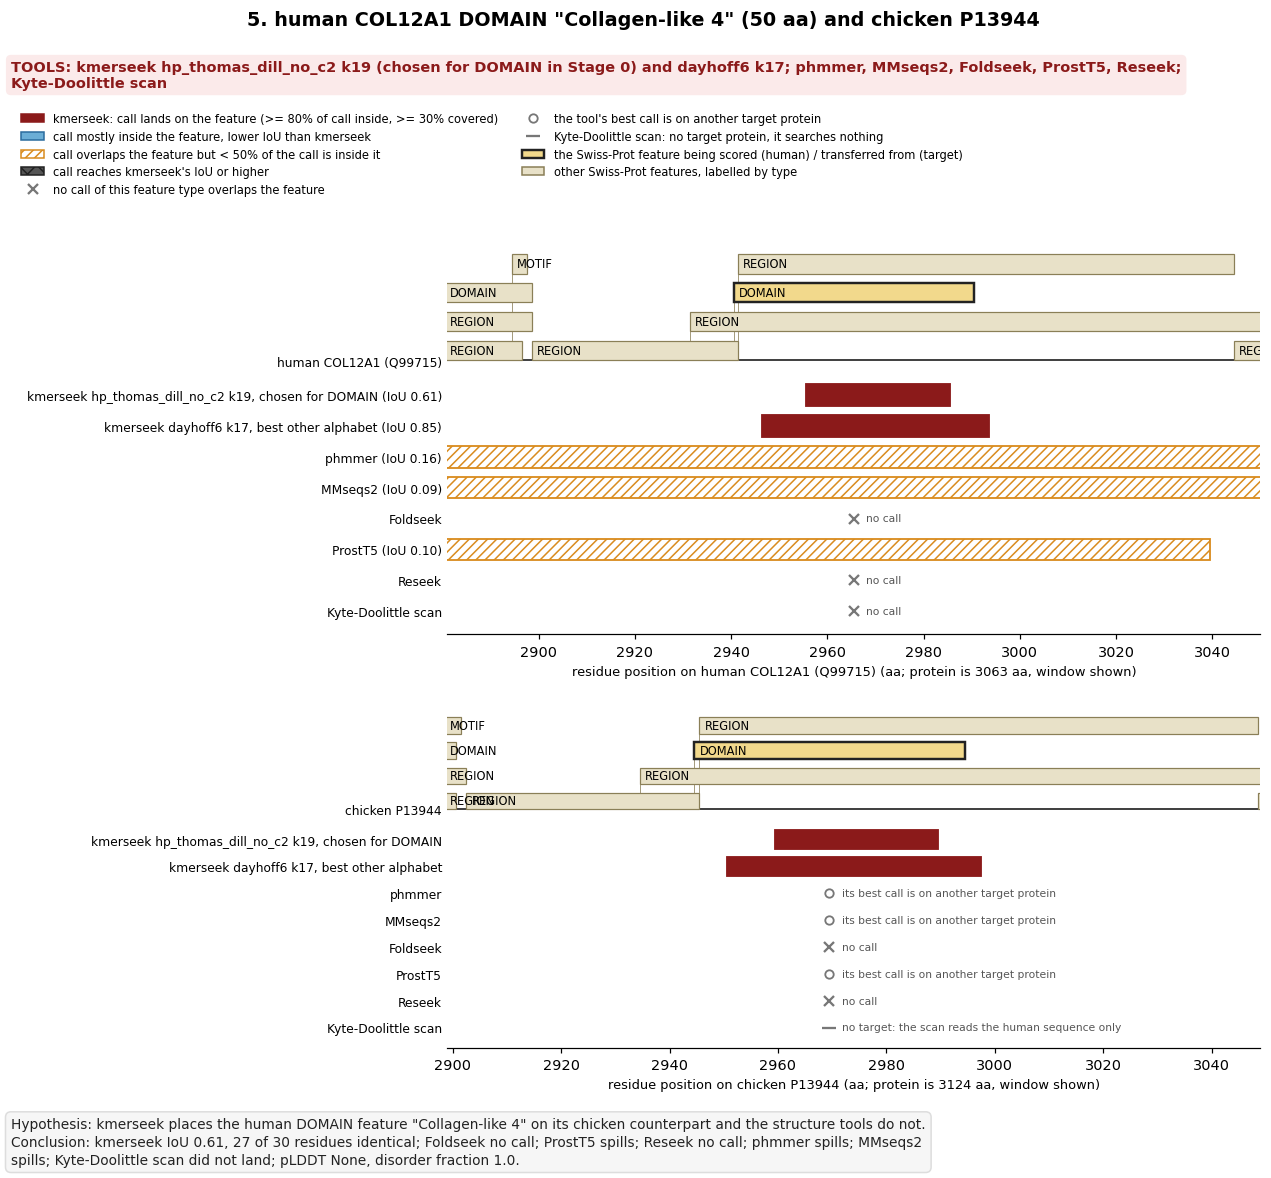

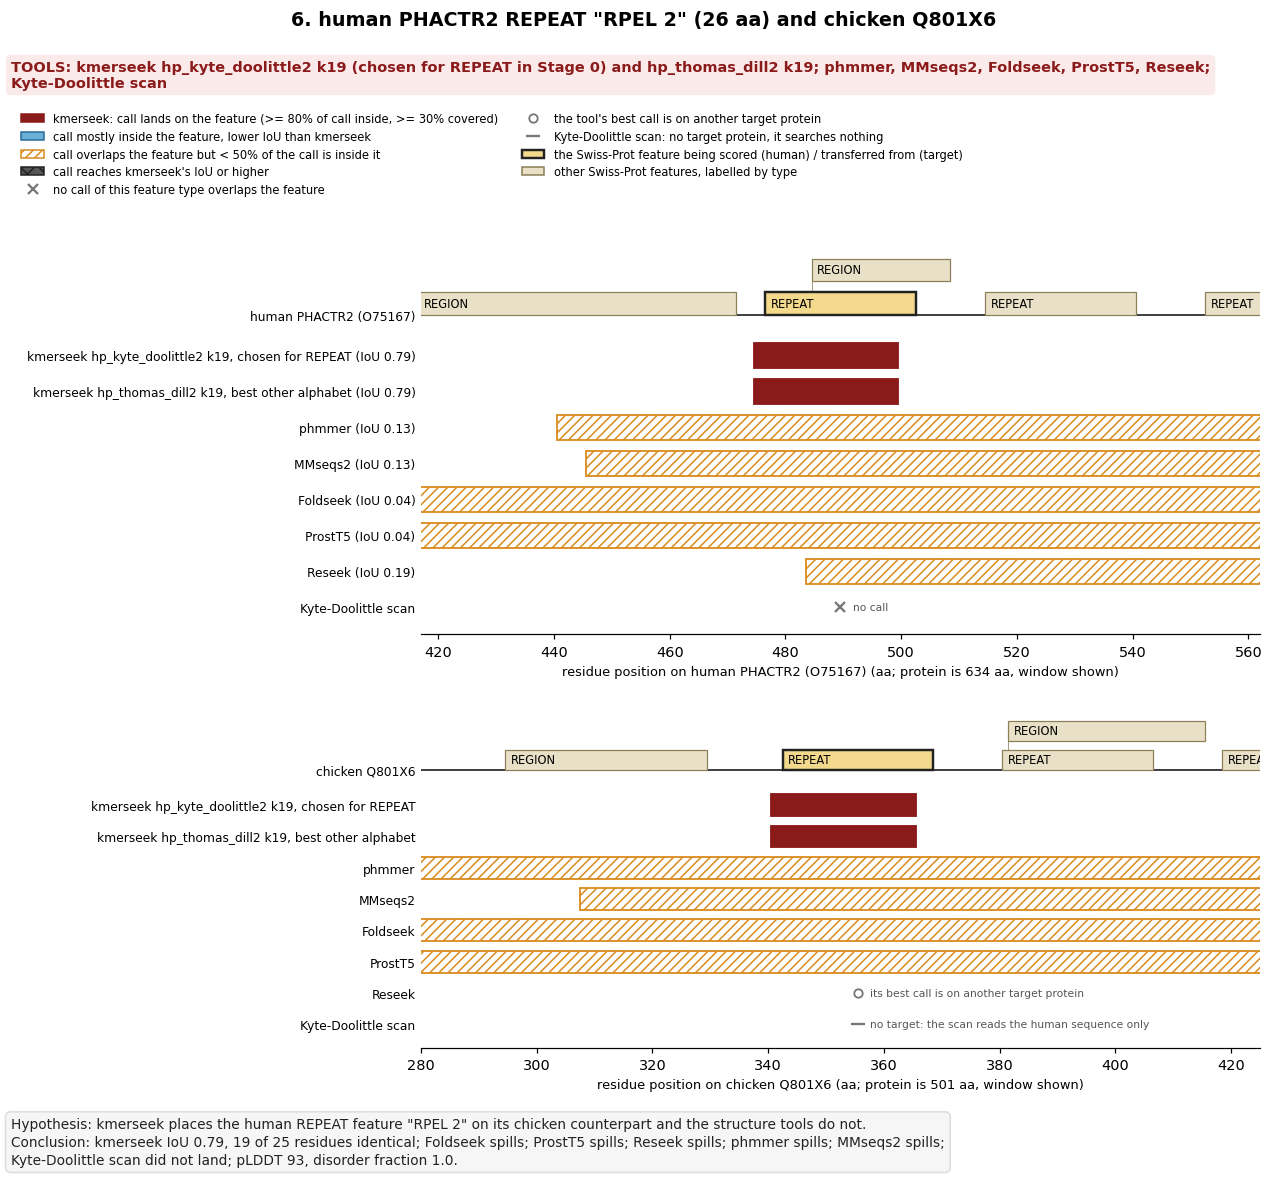

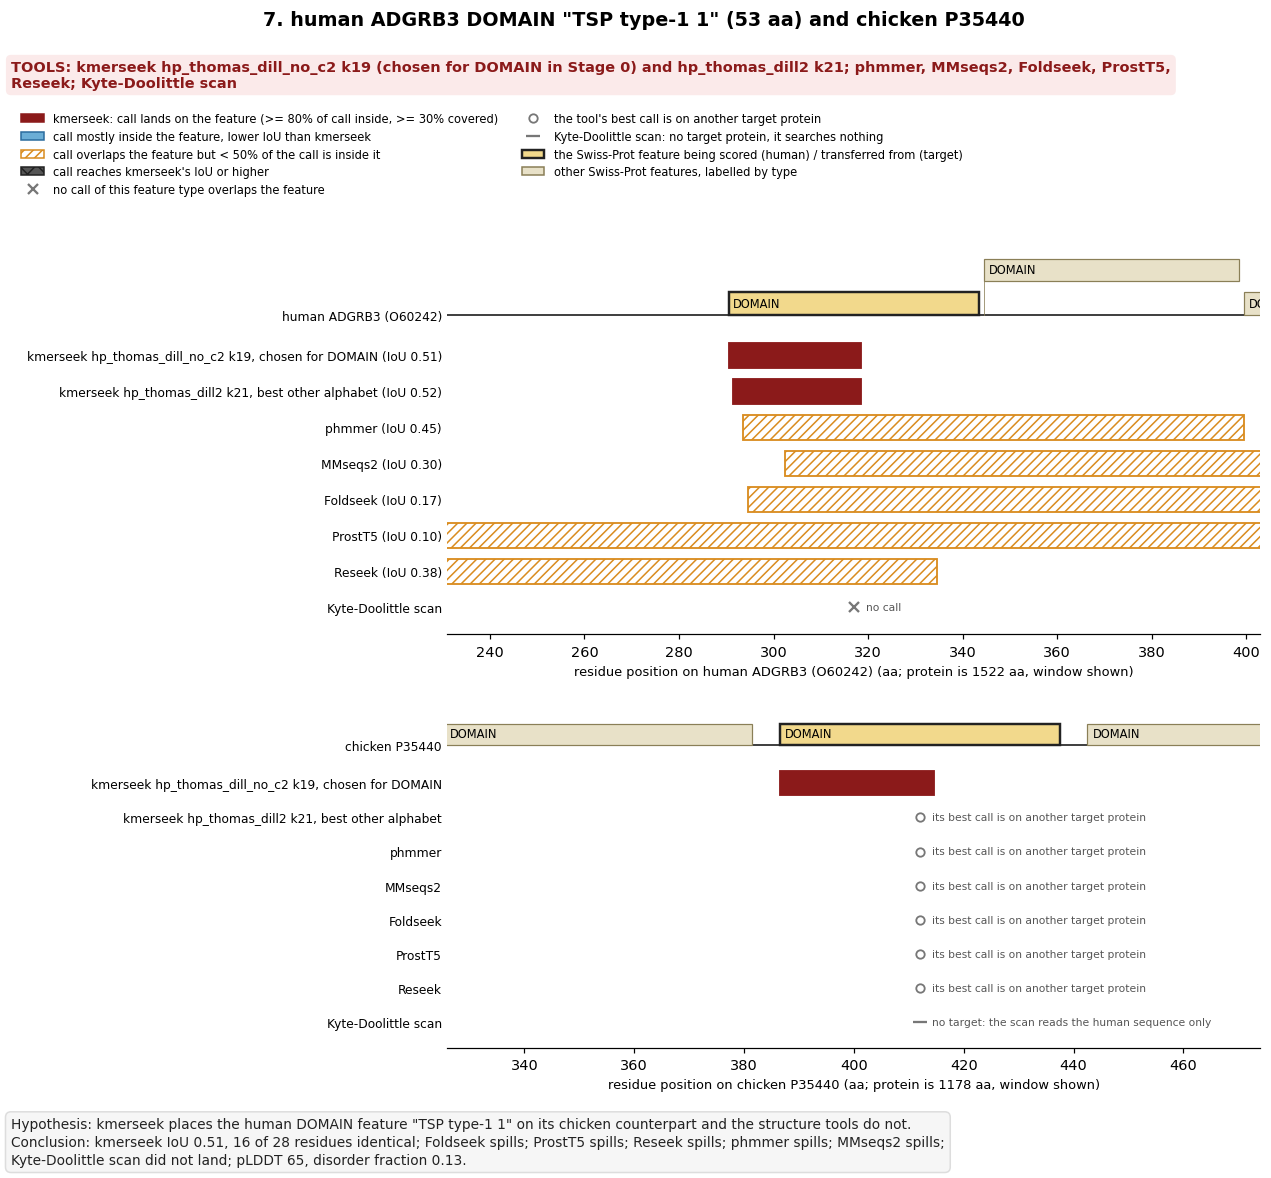

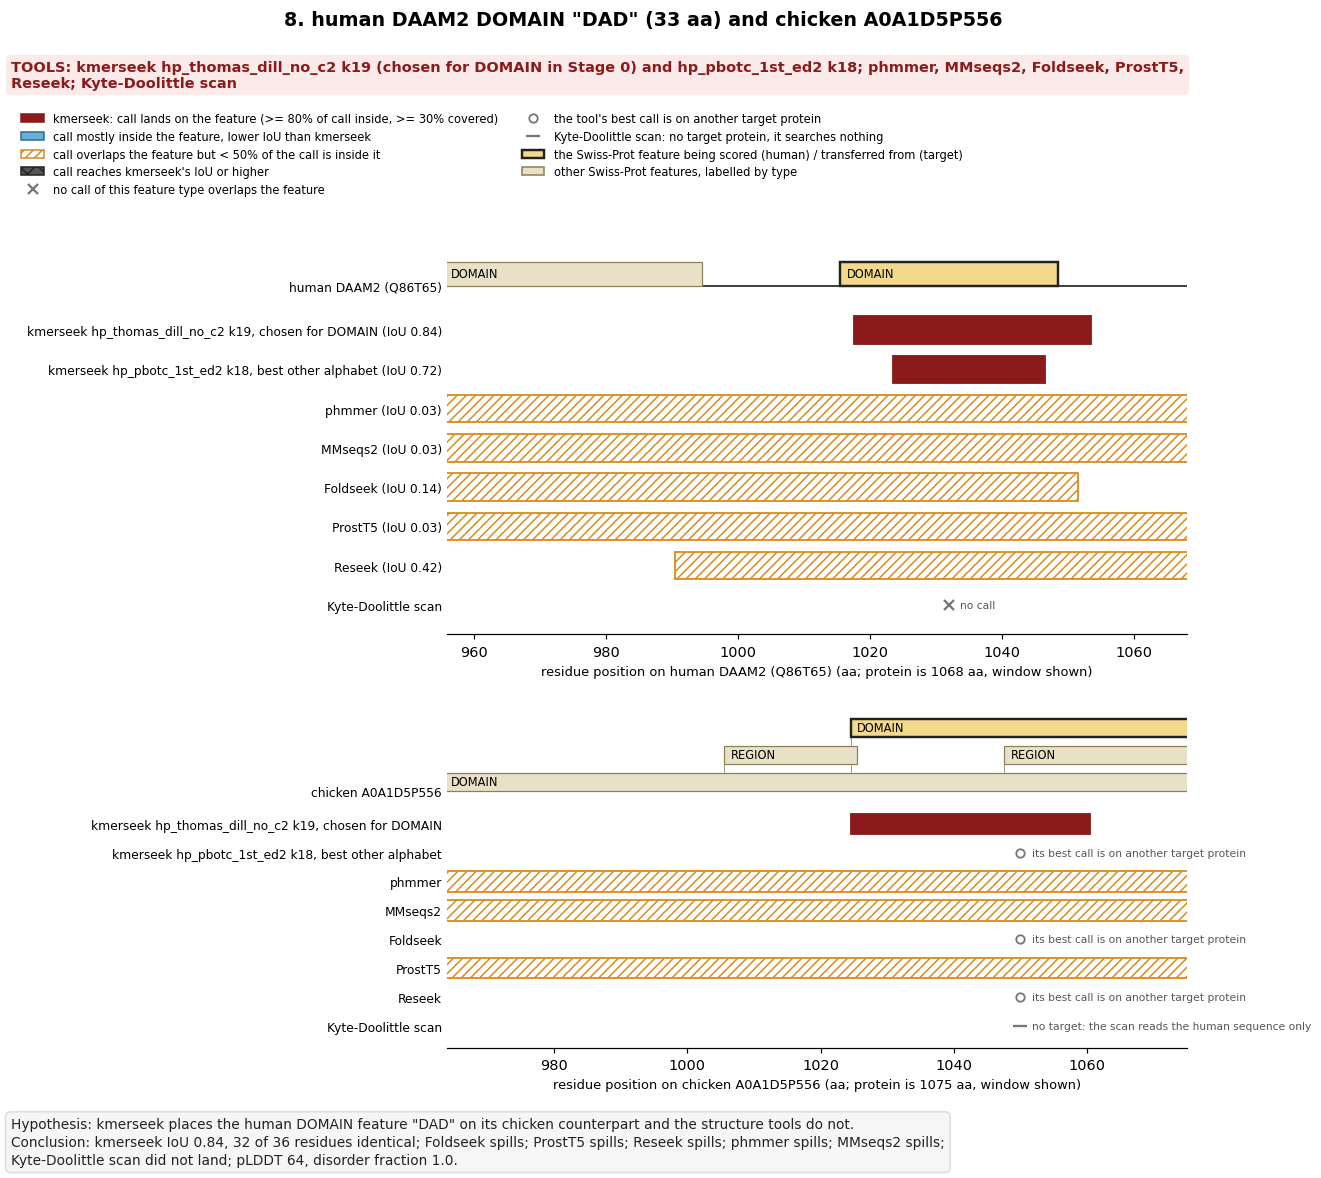

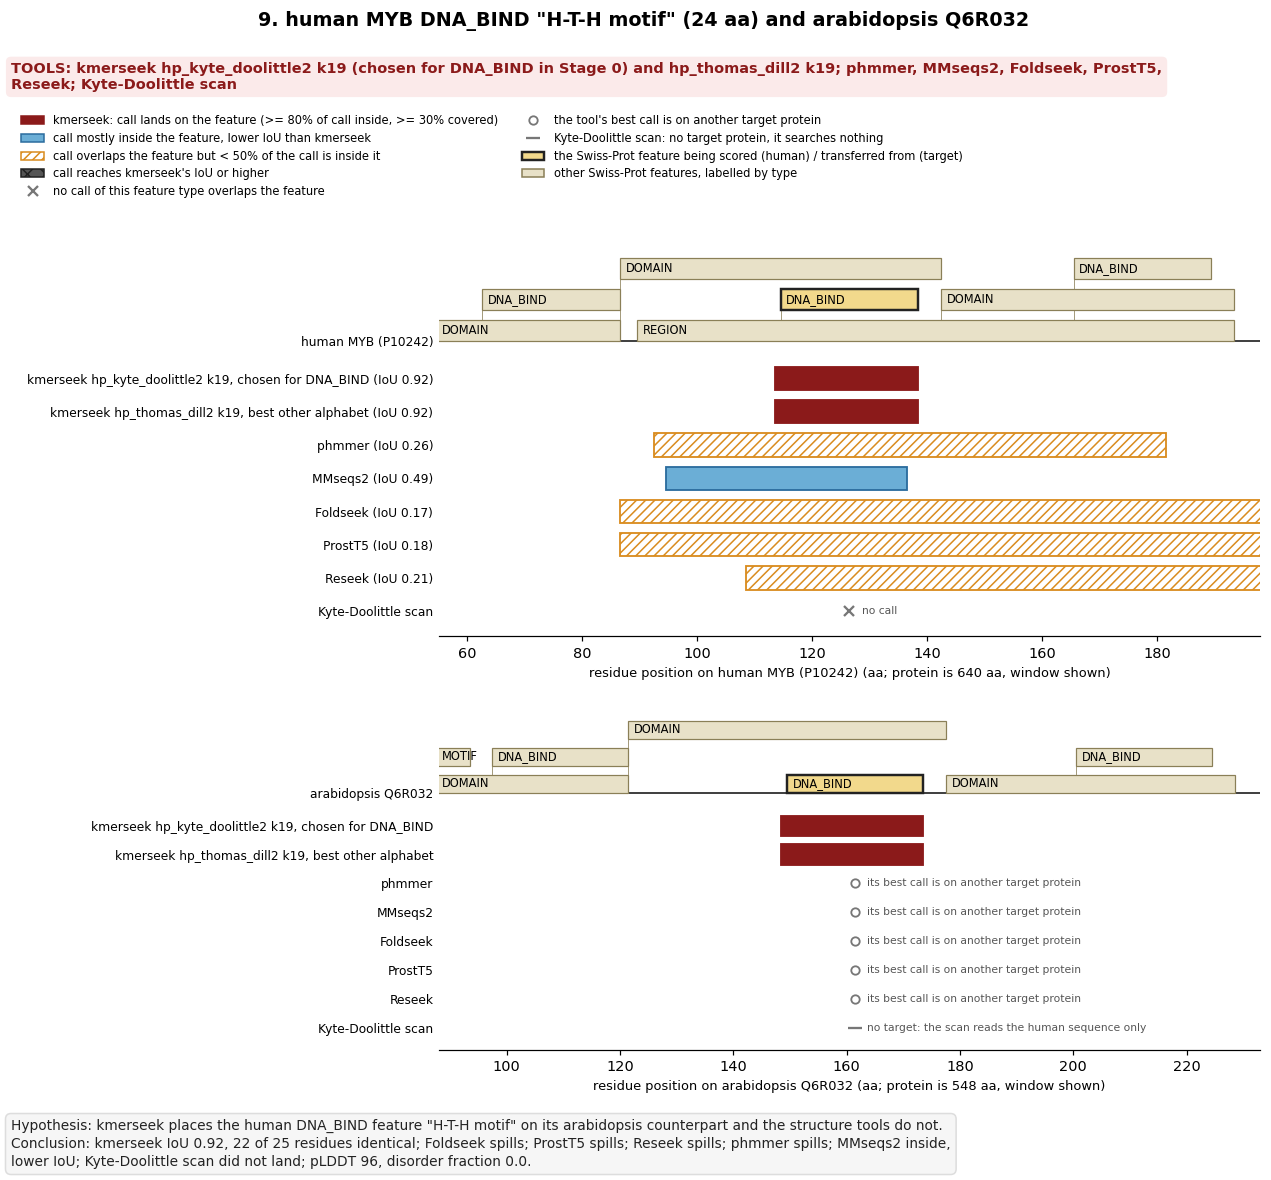

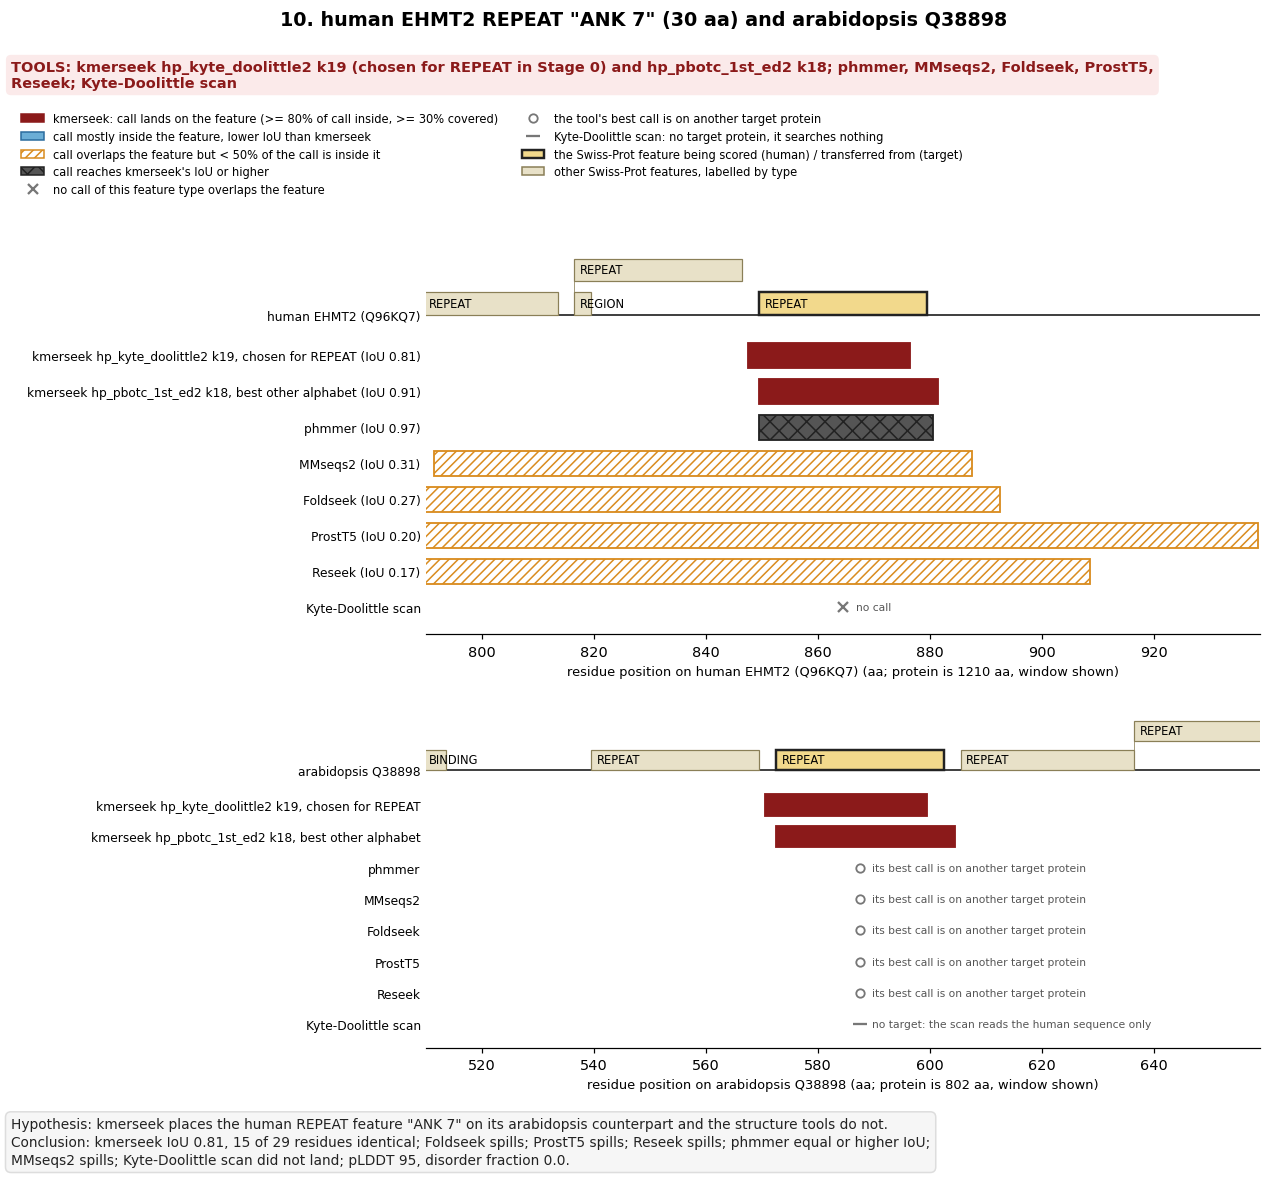

In [9]:
notes = pl.read_parquet(he.EXTRACT / "244_swissprot_feature_notes.parquet")
for i, r in enumerate(TOP.iter_rows(named=True), start=1):
    oth = (
        L.filter(
            (pl.col("arm") == r["other_arm"]) & (pl.col("species") == r["species"])
        )
        .join(pl.DataFrame({k: [r[k]] for k in KEY}), on=KEY, how="semi")
        .row(0, named=True)
    )
    fig = he.draw_candidate(r, oth, notes)
    outcome = "; ".join(
        f"{lab} {r[f'{lab}|category']}"
        for lab in ["Foldseek", "ProstT5", "Reseek", "phmmer", "MMseqs2"]
    )
    sym = r["hgnc_symbol"] or r["accession"]
    mu.finish_figure(
        fig,
        FIG / f"244_candidate_{i:02d}_{sym}_{r['pfam_id']}_{r['species']}.png",
        tools=f"kmerseek {he.arm_short(r['chosen_arm'])} (chosen for {r['pfam_id']} in Stage 0) and {he.arm_short(r['other_arm'])}; phmmer, MMseqs2, Foldseek, ProstT5, Reseek; Kyte-Doolittle scan",
        hypothesis=f"kmerseek places the human {r['pfam_id']} feature \"{he.short_note(r['note'])}\" on its {r['species']} counterpart and the structure tools do not.",
        conclusion=(
            f"kmerseek IoU {r['land_iou']:.2f}, {r['n_identical']} of {r['region_length']} residues identical; {outcome}; "
            f"Kyte-Doolittle scan {'landed' if r['kd_landed'] else 'did not land'}; "
            f"pLDDT {r['mean_plddt_region'] if r['mean_plddt_region'] is None else round(r['mean_plddt_region'])}, "
            f"disorder fraction {r['disorder_fraction_region'] if r['disorder_fraction_region'] is None else round(r['disorder_fraction_region'], 2)}."
        ),
        title=f"{i}. human {sym} {r['pfam_id']} \"{he.short_note(r['note'])}\" ({r['feature_length']} aa) and {r['species']} {r['land_target_acc']}",
        layout=False,
    )

## Verdict: the facts it rests on

The hero is picked from the top 10 in rank order by one rule. It is the first case that
meets three conditions. Its feature type is one of criterion 6's named types (BINDING and
SITE are not on that list). The scan did not land on it. No comparison tool, sequence or
structure, reaches kmerseek's IoU. The backup is the next case under the same rule whose Swiss-Prot
description, without its number, differs from the hero's (so a second copy of the same
repeat family is skipped and listed).

In [10]:
NAMED6 = [
    "ZN_FING",
    "MOTIF",
    "DOMAIN",
    "REPEAT",
    "DNA_BIND",
    "COILED",
    "TRANSMEM",
    "INTRAMEM",
    "REGION (named)",
]
ALL_TOOLS = [f"{lab}|category" for lab in he.COMPARISON_ARMS.values()]
T = TOP.with_row_index("rank", offset=1).with_columns(
    rule=pl.col("feature_label").is_in(NAMED6)
    & pl.all_horizontal([pl.col(c) != "equal or higher IoU" for c in ALL_TOOLS]),
    family=pl.col("note").str.replace(r"\s*\d+$", ""),
)
print(
    T.select(
        "rank",
        pl.col("hgnc_symbol").alias("gene"),
        "pfam_id",
        "note",
        "species",
        "rule",
        *[pl.col(c).alias(c.split("|")[0]) for c in ALL_TOOLS],
    )
)
ok = T.filter("rule")
HERO = ok.row(0, named=True)
rest = ok.filter(pl.col("rank") > HERO["rank"])
skipped = rest.filter(pl.col("family") == HERO["family"])
BACKUP = rest.filter(pl.col("family") != HERO["family"]).row(0, named=True)
print(
    f"\nskipped as the same family as the hero: {[(r['rank'], r['hgnc_symbol'], r['note'], r['species']) for r in skipped.iter_rows(named=True)]}"
)
for tag, r in (("HERO", HERO), ("BACKUP", BACKUP)):
    print(
        f"\n{tag}: rank {r['rank']}, human {r['hgnc_symbol']} ({r['accession']}) {r['pfam_id']} "
        f"\"{r['note']}\" {r['domain_start']}-{r['domain_end']} ({r['feature_length']} aa)"
    )
    print(
        f"  target: {r['species']} {r['land_target_acc']} = {he.protein_name(r['species'], r['land_target_acc'])}"
    )
    print(
        f"  kmerseek {he.arm_short(r['chosen_arm'])}: call {r['land_qstart'] + 1}-{r['land_qend']}, IoU {r['land_iou']:.2f}, "
        f"{r['n_identical']} of {r['region_length']} residues identical; {r['n_arms_landed']} mask-on arms in "
        f"{r['n_alphabets_landed']} alphabets land on it"
    )
    for lab in he.COMPARISON_ARMS.values():
        cat = r[f"{lab}|category"]
        where = (
            ""
            if cat == "no call"
            else (
                f", call {r[f'{lab}|best_qstart']}-{r[f'{lab}|best_qend']} "
                f"({r[f'{lab}|best_qend'] - r[f'{lab}|best_qstart'] + 1} aa), IoU {r[f'{lab}|best_iou']:.2f}"
            )
        )
        print(f"  {lab}: {cat}{where}")
    print(f"  Kyte-Doolittle scan landed: {r['kd_landed']}")
    pl_ = None if r["mean_plddt_region"] is None else round(r["mean_plddt_region"], 1)
    dis_ = (
        None
        if r["disorder_fraction_region"] is None
        else round(r["disorder_fraction_region"], 2)
    )
    print(
        f"  mean pLDDT over the feature: {pl_}, fraction of residues metapredict calls disordered: {dis_}"
    )
    print(f"  species passing: {r['species_passing']}")

# Criterion 7 ranks before species distance, so the farthest cases of each named type can sit
# below the top 10. The farthest one per type, among cases passing every criterion:
far = (
    one_per_instance(
        POOL.filter(~pl.col("kd_landed") & pl.col("feature_label").is_in(NAMED6))
    )
    .with_columns(
        no_tool_higher=pl.all_horizontal(
            [pl.col(c) != "equal or higher IoU" for c in ALL_TOOLS]
        )
    )
    .sort(["mya", "no_tool_higher", "n_arms_landed"], descending=True)
    .group_by("feature_label", maintain_order=True)
    .first()
)
print("\nFarthest passing case per named feature type:")
print(
    far.select(
        pl.col("hgnc_symbol").alias("gene"),
        "feature_label",
        "note",
        pl.col("feature_length").alias("len"),
        "species",
        pl.col("land_target_acc").alias("target"),
        pl.col("land_iou").round(2).alias("km IoU"),
        pl.col("identity_pct").round(0).alias("id %"),
        pl.col("n_arms_landed").alias("arms"),
        "no_tool_higher",
        "low_confidence",
        *[pl.col(f"{lab}|category").alias(lab) for lab in he.STRUCTURE_ARMS.values()],
        pl.col("species_passing"),
    ).sort("feature_label")
)

shape: (10, 12)
┌──────┬─────────┬──────────┬─────────────────┬─────────────┬───────┬──────────┬─────────┬─────────┬─────────────────────┬───────────────────┬─────────────────────┐
│ rank ┆ gene    ┆ pfam_id  ┆ note            ┆ species     ┆ rule  ┆ Foldseek ┆ ProstT5 ┆ Reseek  ┆ phmmer              ┆ MMseqs2           ┆ MMseqs2 iterative   │
│ ---  ┆ ---     ┆ ---      ┆ ---             ┆ ---         ┆ ---   ┆ ---      ┆ ---     ┆ ---     ┆ ---                 ┆ ---               ┆ ---                 │
│ u32  ┆ str     ┆ str      ┆ str             ┆ str         ┆ bool  ┆ str      ┆ str     ┆ str     ┆ str                 ┆ str               ┆ str                 │
╞══════╪═════════╪══════════╪═════════════════╪═════════════╪═══════╪══════════╪═════════╪═════════╪═════════════════════╪═══════════════════╪═════════════════════╡
│ 1    ┆ ROS1    ┆ BINDING  ┆ ligand: ATP     ┆ yeast       ┆ false ┆ spills   ┆ spills  ┆ spills  ┆ spills              ┆ spills            ┆ spills          

## Verdict

**Candidates.** 87 cases pass every criterion, and the scan landed on 1 of them: SLC26A8, a TRANSMEM helix, in zebrafish. The other 86 cover 49 distinct human features. TRANSMEM does not fill the list: 4 TRANSMEM cases pass every criterion. The rows are mostly BINDING (31, all 9-aa features with ligand ATP), INTRAMEM (16, the pore-forming segments of KCNK5, KCNK16 and KCNK17), REPEAT (13) and ZN_FING (13).

**Hero: human COL9A1 "Collagen-like 7" (residues 655-712, 58 aa), placed in chicken P12106, the collagen alpha-1(IX) chain.**

- kmerseek hp_thomas_dill_no_c2 k19 calls 669-700 (IoU 0.56), with 25 of 32 residues identical. 92 mask-on arms in 8 alphabets land on the feature.
- Every comparison tool's call spills: Foldseek 43-738 (IoU 0.08), ProstT5 44-786 (0.08), Reseek 653-776 (0.46), phmmer 1-918 (0.06), MMseqs2 1-917 (0.06).
- The failure is the width of the call: each tool aligns the chicken chain across the whole collagenous stretch or the whole protein, and the benchmark turns one alignment into one interval.
- The AlphaFold model the structure tools search has mean pLDDT 46.8 over these residues, and metapredict calls all of them disordered. So there is no confident structure for the structure tools to place the domain on.
- The Kyte-Doolittle scan did not land on it. The residues printed above are Gly-X-Y triplets, like the Collagen-like domains on either side. What kmerseek places here is one domain within a repeat array, not a pattern a scan could not see.

**Backup: human PHACTR2 "RPEL 2" (residues 477-502, 26 aa), placed in chicken Q801X6, phosphatase and actin regulator 1 (the PHACTR1 paralog).**

- kmerseek hp_kyte_doolittle2 k19 calls 475-499 (IoU 0.79), with 19 of 25 residues identical. 39 mask-on arms in 7 alphabets land on the feature.
- Every comparison tool spills: Foldseek 69-634 (0.04), ProstT5 68-634 (0.04), Reseek 484-571 (0.19), phmmer 441-634 (0.13), MMseqs2 446-634 (0.13).
- AlphaFold's mean pLDDT over the repeat is 93.3, so the structure tools do have a confident model. The failure is the spilled boundary alone.
- metapredict calls every residue disordered, which is what puts this case under criterion 7.
- The scan did not land on it.

The next case of the same kind as the hero, COL12A1 "Collagen-like 4" in chicken (rank 5), is skipped under the rule stated above.

**Distance.** Hero and backup are both in chicken (300 Mya), because criterion 7 ranks before species distance. Among cases passing every criterion, the farthest of each named type are:

- **MYB "H-T-H motif" in Arabidopsis:** 111 arms land on it, IoU 0.92, 88% identical. MMseqs2 has a call inside the motif with lower IoU.
- **HIVEP1 "C2H2-type 4" in worm:** IoU 0.88, 78% identical, 97 arms. Foldseek and Reseek have no call, and ProstT5 spills.

No tool reaches kmerseek's IoU on either case, and neither meets criterion 7. HIVEP1 is the case if distance is ranked above criterion 7 and the hero must be a ZN_FING.